input_file = 'D:/Research/microfluid_pgl_meg/mf_.5fl_5pgl_1/asymetric_distribution/series_stat/angle_data.xlsx' 绘制不对称性向量与运动方向夹角的角度直方图

Analysis complete. R-value: 0.3013, p-value: 5.3375e-04


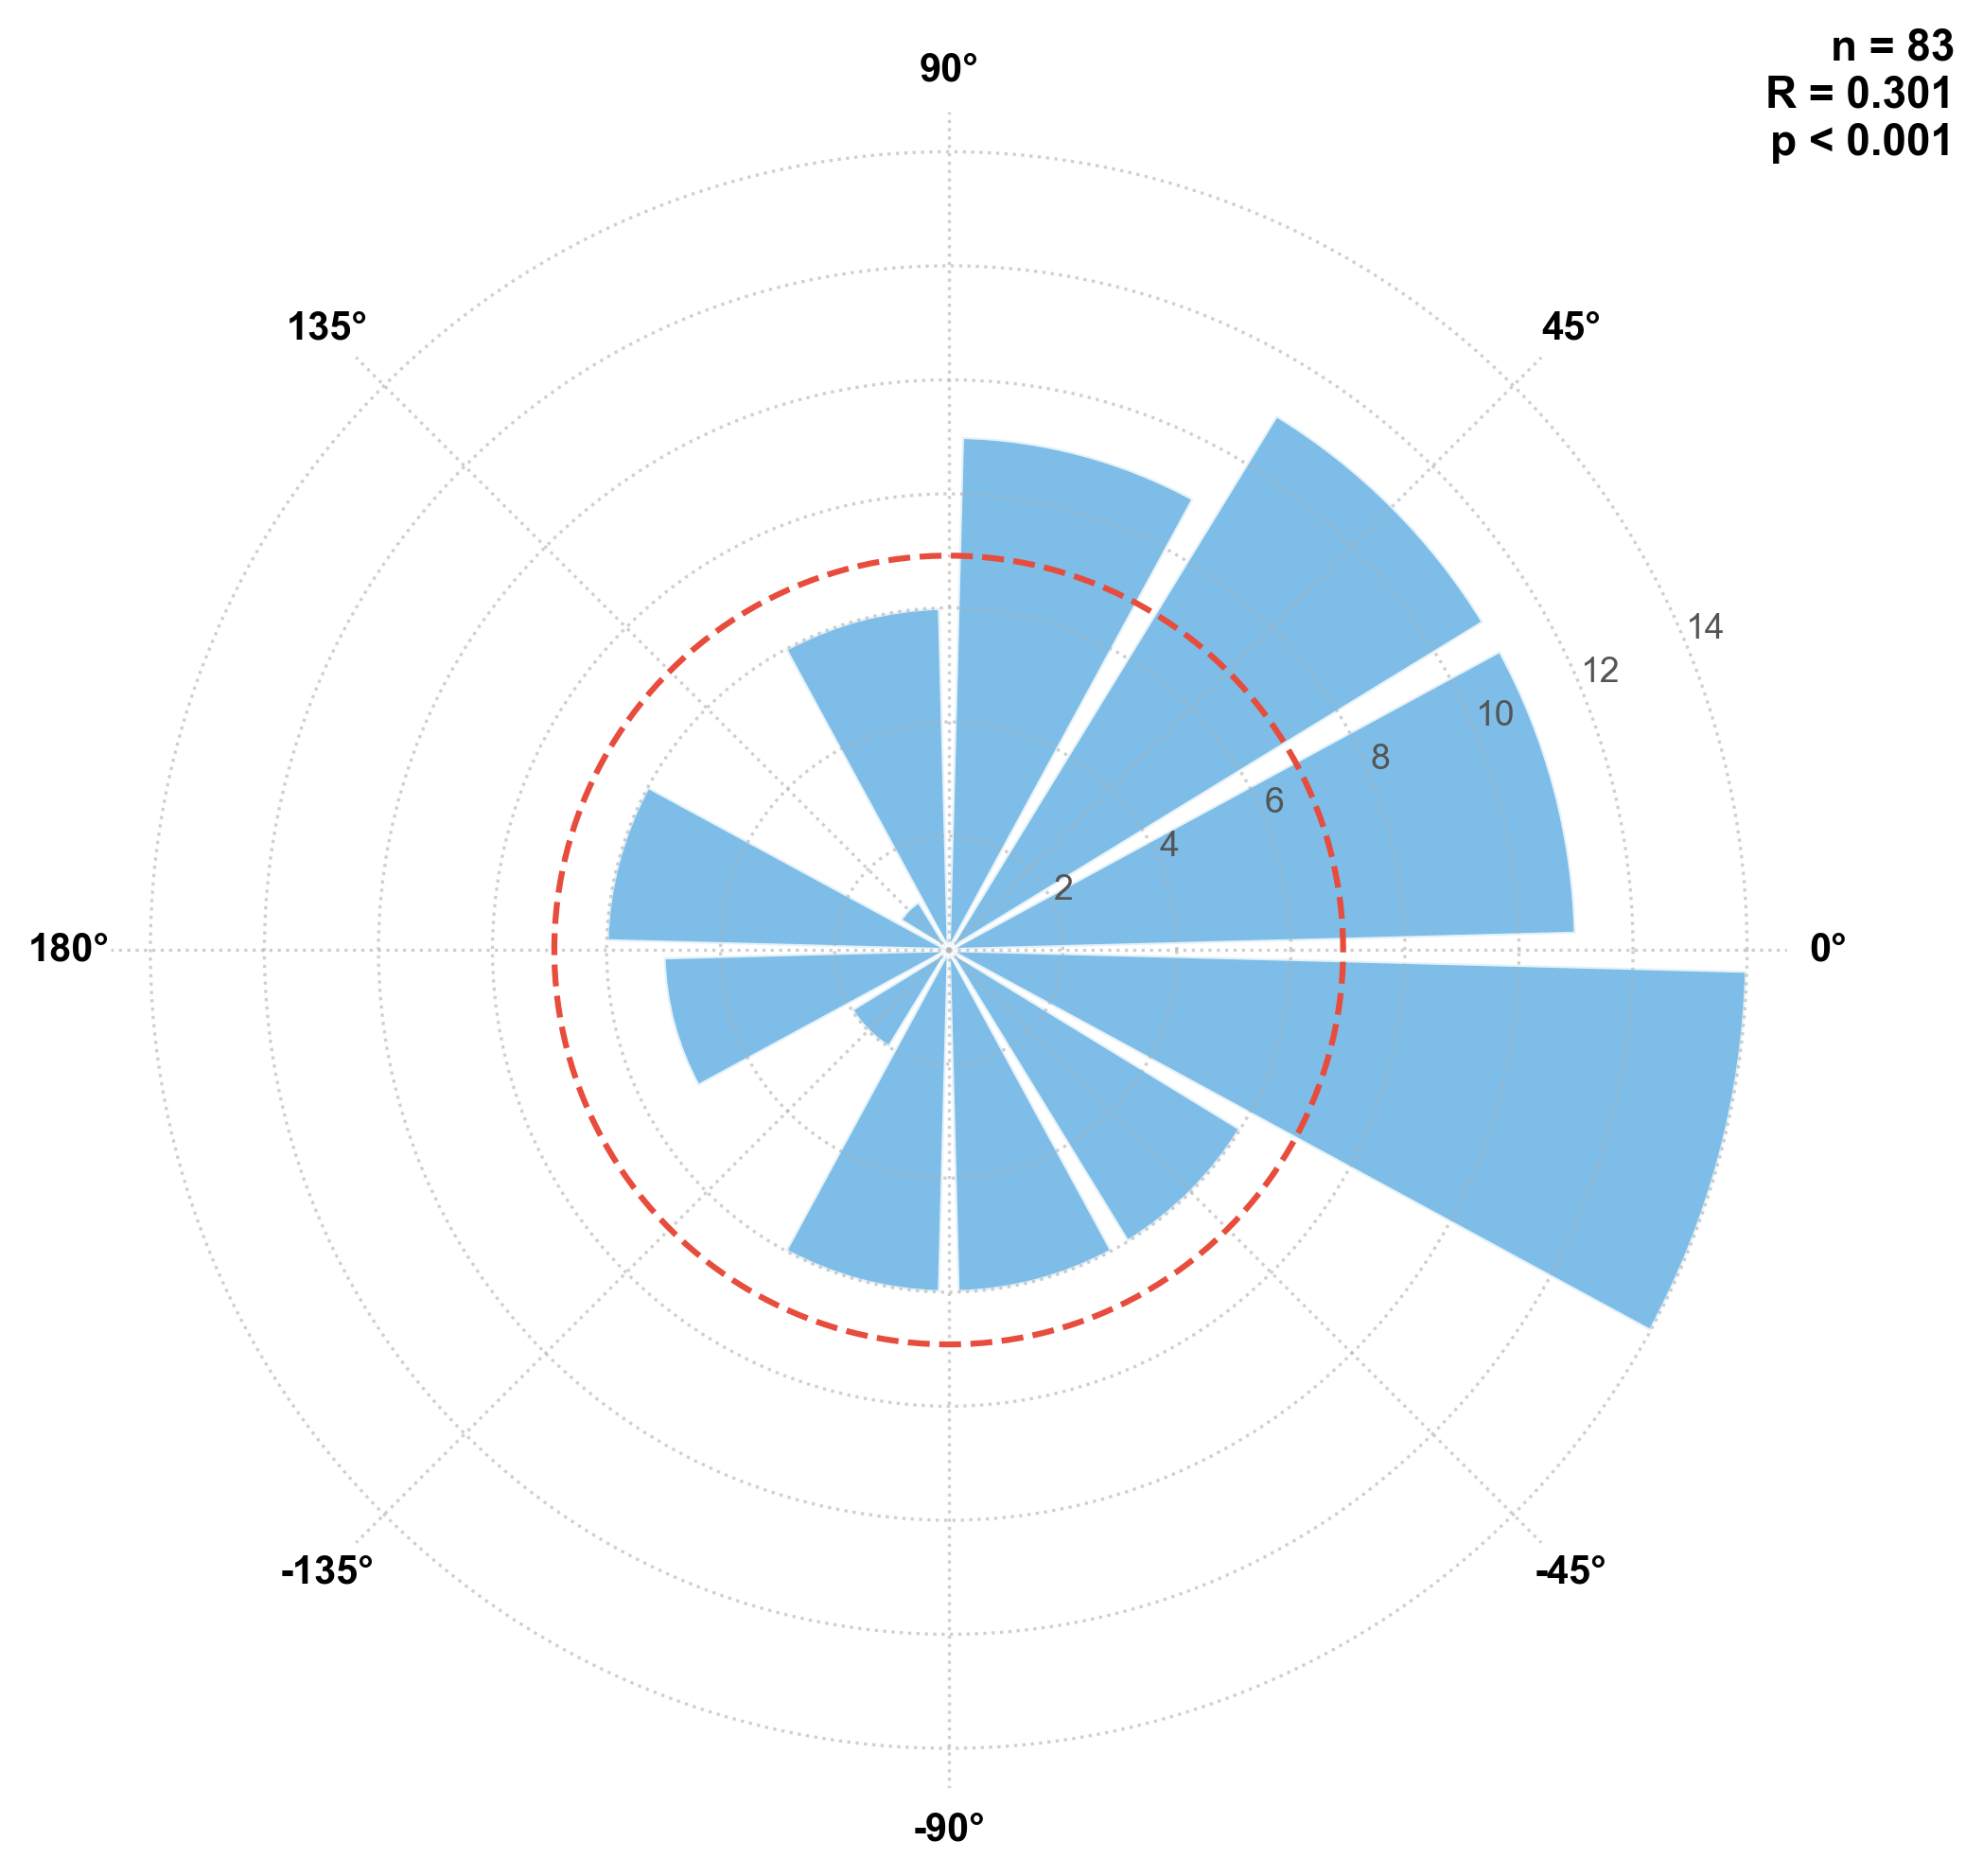

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIGURATION AREA ================= #
input_file = 'D:/Research/microfluid_pgl_meg/mf_.5fl_5pgl_1/asymetric_distribution/series_stat/angle_data.xlsx'
column_name = 'angle' 
output_file = 'directional_analysis_polar.svg'

use_dummy_data = True  # Set to False for real data
num_bins = 12 

# Visual Constants
BAR_COLOR = '#5DADE2'
UNIFORM_COLOR = '#E74C3C' # Red for the reference circle
FONT_NAME = 'Arial'
# ====================================================== #

# 1. Data Processing
df = pd.read_excel(input_file)

angles = df[column_name].values
radians = np.deg2rad(angles)
n_samples = len(angles)

# 2. Directional Statistics (Rayleigh Test)
# Calculate components of the resultant vector
sum_cos = np.sum(np.cos(radians))
sum_sin = np.sum(np.sin(radians))

# Resultant vector length (R) - indicates degree of directionality
R_length = np.sqrt(sum_cos**2 + sum_sin**2) / n_samples
# Rayleigh's Z statistic and p-value approximation
z_stat = n_samples * (R_length**2)
p_value = np.exp(-z_stat) 

# 3. Histogram Calculation
bin_counts, bin_edges = np.histogram(radians, bins=num_bins, range=(-np.pi, np.pi))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
uniform_level = n_samples / num_bins # Theoretical frequency if distribution was random

# 4. Plotting
plt.rcParams['font.family'] = FONT_NAME
fig = plt.figure(figsize=(7, 7), dpi=300)
ax = fig.add_subplot(111, projection='polar')

# Setup orientation
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)

# Plot bars (zorder 2)
ax.bar(bin_centers, bin_counts, width=bin_width*0.9, color=BAR_COLOR, 
       edgecolor='white', linewidth=1, alpha=0.8, zorder=2)

# Plot Uniform Distribution Circle (zorder 3)
theta_full = np.linspace(0, 2*np.pi, 200)
ax.plot(theta_full, [uniform_level]*200, color=UNIFORM_COLOR, 
        linestyle='--', linewidth=1.5, label='Uniform Expected', zorder=3)

# 5. Styling and Labels
# Set ticks to -180 to 180
degree_ticks = np.arange(0, 360, 45)
ax.set_xticks(np.deg2rad(degree_ticks))
ax.set_xticklabels([f"{d}°" if d <= 180 else f"{d-360}°" for d in degree_ticks], 
                   fontweight='bold', fontsize=10)

# Ensure radial labels are on top (zorder 10)
ax.set_axisbelow(False)
plt.yticks(fontsize=9, color='#555555', zorder=10)
ax.set_rlabel_position(22.5)
ax.grid(True, linestyle=':', alpha=0.6, zorder=1)
ax.spines['polar'].set_visible(False)

# 6. Statistical Annotation
stats_text = (f"n = {n_samples}\n"
              f"R = {R_length:.3f}\n"
              f"p < {0.001 if p_value < 0.001 else round(p_value, 3)}")

# Place text box in the upper right corner of the figure
ax.text(1.1, 1.05, stats_text, transform=ax.transAxes, 
        fontsize=11, fontweight='bold', va='top', ha='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# 7. Final Output
plt.tight_layout()
plt.savefig(output_file, format='svg', transparent=True)
print(f"Analysis complete. R-value: {R_length:.4f}, p-value: {p_value:.4e}")
plt.show()

归一化原点发散图 (Origin-Normalized Trajectories)

形式：将所有凝聚体的起始坐标 $(x_0, y_0)$ 强制归零到 $(0,0)$。

内容：绘制所有 $t$ 时刻的 $(x_t - x_0, y_t - y_0)$。

顶级期刊细节：由于数据量大，不要画实线。使用半透明的散点（Alpha=0.1）或者核密度估计图 (Kernel Density Estimation, KDE) 轮廓线。

结果：如果存在Marangoni效应，图像应呈现为一个偏向梯度方向的“彗星”或“扇形”，而不是各向同性的圆形。

根据凝聚体的尺寸（荧光强度）对轨迹进行颜色编码。



1.极坐标玫瑰图，扇形长度展示角度在指定bin范围的轨迹数量，并计算得到Chemotactic Index (CI)（如果可以计算出误差范围则给出）。Trackmate分析时已经旋转到了X方向即梯度方向。如果有对照可以将两组数据作在同一张图中

2.对于整条轨迹的相关数据信息，tracks文件里的LINEARITY_OF_FORWARD_PROGRESSION列记录了2该条轨迹的FMI。以美观的形式展示其分布



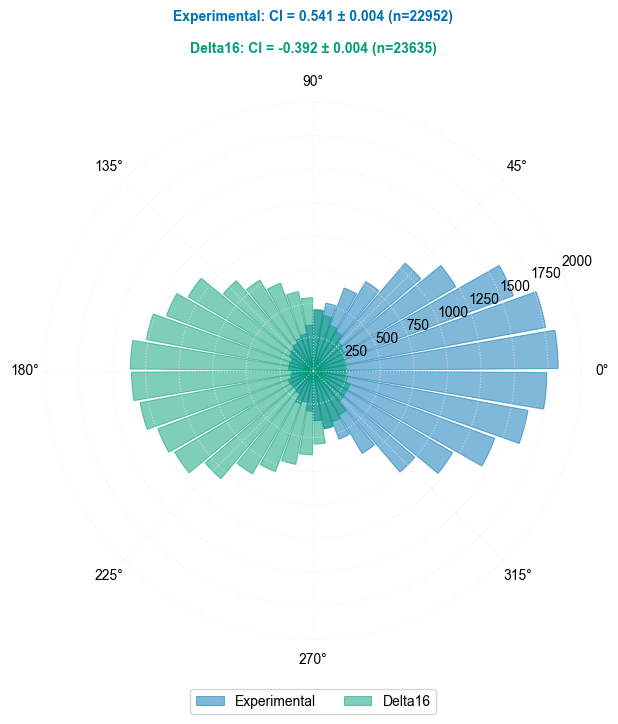

C:\Users\1\AppData\Local\Temp\ipykernel_43996\4270777822.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, inner=None, alpha=0.2, linewidth=0)
C:\Users\1\AppData\Local\Temp\ipykernel_43996\4270777822.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, size=2.5, alpha=0.5, jitter=0.2, dodge=False)


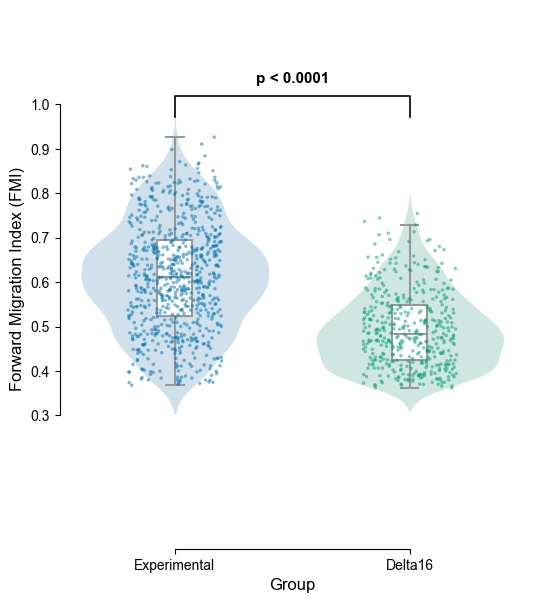

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# ==========================================
# 1. Configuration & Global Settings
# ==========================================
CONFIG = {
    'font_family': 'Arial',
    'save_format': ['svg', 'png'],
    'dpi': 300,
    # Updated the color dictionary as requested; keys directly correspond to the experimental group labels
    'colors': {
        'Control': '#D55E00',       # Orange
        'Experimental': '#0072B2',  # Blue
        'Delta16': '#009E73',       # Green (a high-contrast accessible green is used here)
        'box': '#333333',
        'grid': '#EAEAEA'
    },
    'bins': 36,  
    'default_min_spots': 5,      
    'default_sample_ratio': 1.0  
}

plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['svg.fonttype'] = 'none'

# ==========================================
# 2. Data Processing Modules
# ==========================================

def load_csv_auto(filepath):
    """Automated CSV reader for TrackMate files."""
    try:
        df = pd.read_csv(filepath, header=0)
        test_col = 'LABEL' if 'LABEL' in df.columns else 'Label'
        if test_col not in df.columns:
            df = pd.read_csv(filepath, header=3)
        df.columns = [str(c).upper().strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def calculate_angles_and_ci(files_dict):
    """Calculates segment angles and CI with error ranges."""
    spots_df = load_csv_auto(files_dict['spots'])
    edges_df = load_csv_auto(files_dict['edges'])
    
    if spots_df is None or edges_df is None:
        return None, None

    spot_map = spots_df.set_index('LABEL')[['POSITION_X', 'POSITION_Y']].to_dict('index')
    
    angles, cos_thetas = [], []
    for _, row in edges_df.iterrows():
        edge_label = str(row['LABEL'])
        for sep in ['_', '→', '->']:
            if sep in edge_label:
                parts = edge_label.split(sep)
                break
        else: continue
            
        if len(parts) < 2: continue
        s_id, t_id = parts[0].strip(), parts[1].strip()

        if s_id in spot_map and t_id in spot_map:
            dx = spot_map[t_id]['POSITION_X'] - spot_map[s_id]['POSITION_X']
            dy = spot_map[t_id]['POSITION_Y'] - spot_map[s_id]['POSITION_Y']
            dist = np.sqrt(dx**2 + dy**2) + 1e-9
            
            angles.append(np.arctan2(dy, dx))
            cos_thetas.append(dx / dist)

    res_df = pd.DataFrame({'angle': angles, 'cos_theta': cos_thetas})
    
    # Random sampling of edges
    ratio = files_dict.get('sampling_ratio', CONFIG['default_sample_ratio'])
    if ratio < 1.0:
        res_df = res_df.sample(frac=ratio).reset_index(drop=True)

    stats_dict = {
        'CI_mean': res_df['cos_theta'].mean(),
        'CI_sem': stats.sem(res_df['cos_theta']), 
        'N': len(res_df),
        'name': files_dict.get('label', 'Experiment')
    }
    return res_df, stats_dict

def get_fmi_data(files_dict):
    """Extracts FMI data with track length filtering."""
    tracks_df = load_csv_auto(files_dict['tracks'])
    if tracks_df is None: return None
    
    fmi_col = 'LINEARITY_OF_FORWARD_PROGRESSION'
    spot_col = 'NUMBER_SPOTS'
    
    min_spots = files_dict.get('min_spots', CONFIG['default_min_spots'])
    filtered_df = tracks_df[tracks_df[spot_col] >= min_spots].copy()
    
    return pd.DataFrame({
        'FMI': filtered_df[fmi_col],
        'Group': files_dict.get('label', 'Exp')
    })

# ==========================================
# 3. Visualization Modules
# ==========================================

def plot_rose_diagram(angle_data_list, stats_list, output_name, save_dir):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('E')
    
    max_count = 0
    for i, (angles, stat) in enumerate(zip(angle_data_list, stats_list)):
        # Dynamically match colors: use the configured color if the group name is in CONFIG; otherwise default to black
        color = CONFIG['colors'].get(stat['name'], '#000000')
        
        counts, bin_edges = np.histogram(angles, bins=CONFIG['bins'], range=(-np.pi, np.pi))
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        width = (bin_edges[1] - bin_edges[0])
        max_count = max(max_count, max(counts))
        
        ax.bar(bin_centers, counts, width=width*0.9, bottom=0.0, 
               color=color, alpha=0.5, edgecolor=color, linewidth=0.8, label=stat['name'])
        
        # Adjust text positions to prevent overlap when there are multiple groups
        y_text = 1.15 - (i * 0.06)
        info_str = f"{stat['name']}: CI = {stat['CI_mean']:.3f} ± {stat['CI_sem']:.3f} (n={stat['N']})"
        ax.text(0.5, y_text, info_str, transform=ax.transAxes, ha='center', 
                weight='bold', color=color, fontsize=10)

    ax.set_ylim(0, max_count * 1.1)
    ax.grid(True, color=CONFIG['colors']['grid'], linestyle=':', alpha=0.7)
    ax.spines['polar'].set_visible(False)
    
    # Add legend
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.savefig(os.path.join(save_dir, f"{output_name}_Rose.svg"), bbox_inches='tight')
    plt.show()

def plot_fmi_distribution(all_fmi_df, output_name, save_dir):
    plt.figure(figsize=(6, 7))  # Make it slightly wider to accommodate three groups
    groups = all_fmi_df['Group'].unique()
    
    # Generate the color list dynamically based on the groups present in the current data
    palette = [CONFIG['colors'].get(g, '#000000') for g in groups]
    
    # Base Plot
    sns.violinplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, inner=None, alpha=0.2, linewidth=0)
    sns.boxplot(data=all_fmi_df, x='Group', y='FMI', width=0.15, color='white', linewidth=1.5, showfliers=False)
    sns.stripplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, size=2.5, alpha=0.5, jitter=0.2, dodge=False)
    
    # Updated multi-group statistical testing (use a t-test for exactly two groups; multi-group support can be extended later)
    if len(groups) == 2:
        data1 = all_fmi_df[all_fmi_df['Group'] == groups[0]]['FMI']
        data2 = all_fmi_df[all_fmi_df['Group'] == groups[1]]['FMI']
        t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)
        p_text = f"p = {p_val:.1e}" if p_val >= 0.0001 else "p < 0.0001"
        
        y_max = all_fmi_df['FMI'].max()
        h = y_max * 0.05
        plt.plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.2, c='k')
        plt.text(0.5, y_max + 2.5*h, p_text, ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    elif len(groups) > 2:
        # Automatically run an ANOVA test if there are more than two groups
        grouped_data = [all_fmi_df[all_fmi_df['Group'] == g]['FMI'].dropna() for g in groups]
        f_stat, p_val = stats.f_oneway(*grouped_data)
        p_text = f"ANOVA p = {p_val:.1e}" if p_val >= 0.0001 else "ANOVA p < 0.0001"
        
        y_max = all_fmi_df['FMI'].max()
        plt.text(0.5, y_max * 1.05, p_text, ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

    sns.despine(trim=True)
    plt.ylabel('Forward Migration Index (FMI)', fontsize=12)
    plt.xlabel('Group', fontsize=12)
    plt.ylim(0, plt.ylim()[1] * 1.15) 
    plt.savefig(os.path.join(save_dir, f"{output_name}_FMI.svg"), bbox_inches='tight')
    plt.show()

# ==========================================
# 4. Execution
# ==========================================

if __name__ == "__main__":
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series/"
    
    # Restored the Control group and ensured all label names exactly match the color keys in CONFIG
    experiments = [
        #{
            #'label': 'Control',
            #'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            #'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
            #'tracks': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_tracks.csv'),
            #'min_spots': 20,
            #'sampling_ratio': 0.4
        #},
        {
            'label': 'Experimental',
            'spots': os.path.join(base_dir, 'mf_fl1_spots.csv'),
            'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
            'tracks': os.path.join(base_dir, 'mf_fl1_tracks.csv'),
            'min_spots': 20,
            'sampling_ratio': 1.0
        },
        {
            'label': 'Delta16',
            'spots': os.path.join(base_dir, 'mf_delta_1_spots.csv'),
            'edges': os.path.join(base_dir, 'mf_delta_1_edges.csv'),
            'tracks': os.path.join(base_dir, 'mf_delta_1_tracks.csv'),
            'min_spots': 20,
            'sampling_ratio': 1.0
        }
    ]

    angle_list, stats_list, fmi_dfs = [], [], []

    for exp in experiments:
        df_ang, s_dict = calculate_angles_and_ci(exp)
        if df_ang is not None:
            angle_list.append(df_ang['angle'])
            stats_list.append(s_dict)
            
        df_fmi = get_fmi_data(exp)
        if df_fmi is not None:
            fmi_dfs.append(df_fmi)

    if angle_list: plot_rose_diagram(angle_list, stats_list, "Comparison", base_dir)
    if fmi_dfs: plot_fmi_distribution(pd.concat(fmi_dfs), "Comparison", base_dir)

    [Frame Range] Spots: kept 68606/68862 rows (frames 1-200)
    [Warning] 'Edges' has no FRAME column; frame range (1, 200) NOT applied
[Control] Frame window 1-200: kept 68606/68862 spots
[Control] FMI Segment Processing: overlapping segments = 4700, kept (>= 20 spots in window) = 730
    [Frame Range] Spots: kept 23645/23689 rows (frames 1-200)
    [Warning] 'Edges' has no FRAME column; frame range (1, 200) NOT applied
[Experimental] Frame window 1-200: kept 23645/23689 spots
[Experimental] FMI Segment Processing: overlapping segments = 737, kept (>= 20 spots in window) = 730
    [Frame Range] Spots: kept 6001/9358 rows (frames 15-50)
    [Warning] 'Edges' has no FRAME column; frame range (15, 50) NOT applied
[0.5-1 gradient] Frame window 15-50: kept 6001/9358 spots
[0.5-1 gradient] FMI Segment Processing: overlapping segments = 619, kept (>= 12 spots in window) = 179


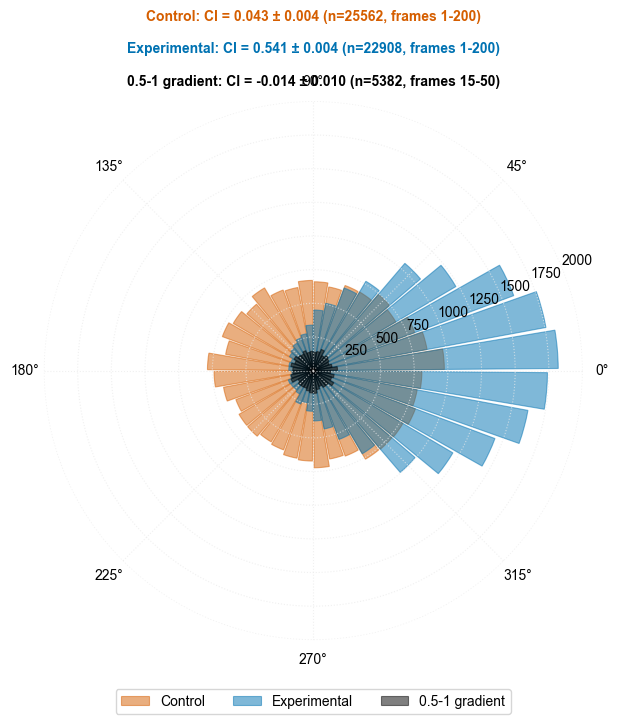


================ FMI Sample Sizes (N) ================
Group 'Control': N = 730 segments
Group 'Experimental': N = 730 segments
Group '0.5-1 gradient': N = 179 segments

========== Pairwise Welch's t-tests (two-tailed) ==========
  Control vs Experimental: t = -62.347, p < 0.0001 (****)
  Control vs 0.5-1 gradient: t = -7.409, p < 0.0001 (****)
  Experimental vs 0.5-1 gradient: t = 27.715, p < 0.0001 (****)


C:\Users\1\AppData\Local\Temp\ipykernel_53720\1646873272.py:268: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, inner=None, alpha=0.2, linewidth=0)
C:\Users\1\AppData\Local\Temp\ipykernel_53720\1646873272.py:270: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, size=2.5, alpha=0.5, jitter=0.2, dodge=False)


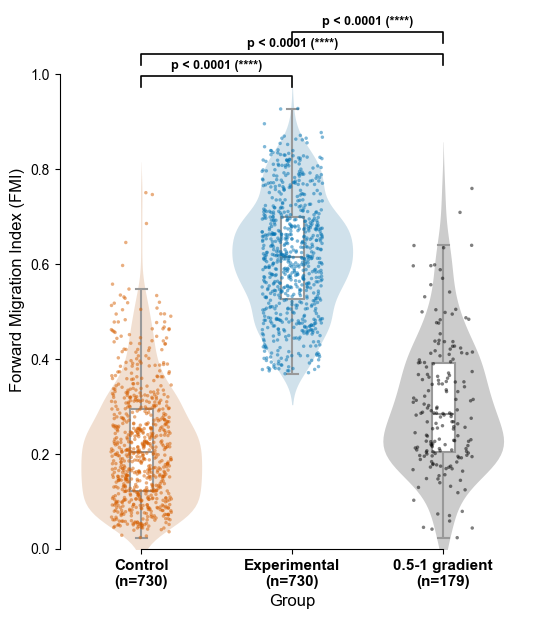

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from itertools import combinations

# ==========================================
# 1. Configuration & Global Settings
# ==========================================
CONFIG = {
    'font_family': 'Arial',
    'save_format': ['svg', 'png'],
    'dpi': 300,
    'colors': {
        'Control': '#D55E00',       # Orange
        'Experimental': '#0072B2',  # Blue
        'Delta16': '#009E73',       # Green
        'box': '#333333',
        'grid': '#EAEAEA'
    },
    'bins': 36,  
    'default_min_spots': 5,      
    'default_sample_ratio': 1.0,
    'default_frame_range': (1, 200)
}

plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['svg.fonttype'] = 'none'

# ==========================================
# 2. Data Processing Modules
# ==========================================

def load_csv_auto(filepath):
    """Automated CSV reader for TrackMate files."""
    try:
        df = pd.read_csv(filepath, header=0)
        test_col = 'LABEL' if 'LABEL' in df.columns else 'Label'
        if test_col not in df.columns:
            df = pd.read_csv(filepath, header=3)
        df.columns = [str(c).upper().strip() for c in df.columns]
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def _filter_frame_range(df, frame_range, df_name):
    """Helper: filter a DataFrame to the given frame window (inclusive)."""
    if 'FRAME' not in df.columns:
        print(f"    [Warning] '{df_name}' has no FRAME column; frame range {frame_range} NOT applied")
        return df
    frame_min, frame_max = frame_range
    n_before = len(df)
    df = df[(df['FRAME'] >= frame_min) & (df['FRAME'] <= frame_max)]
    print(f"    [Frame Range] {df_name}: kept {len(df)}/{n_before} rows (frames {frame_min}-{frame_max})")
    return df

def calculate_angles_and_ci(files_dict, frame_range=None):
    """Calculates segment angles and CI with error ranges.

    :param frame_range: tuple (frame_min, frame_max); only edges/spots within
                        this frame window are used. Default (1, 200).
    """
    if frame_range is None:
        frame_range = CONFIG['default_frame_range']

    spots_df = load_csv_auto(files_dict['spots'])
    edges_df = load_csv_auto(files_dict['edges'])
    
    if spots_df is None or edges_df is None:
        return None, None

    # Frame range filtering for rose-diagram data
    spots_df = _filter_frame_range(spots_df, frame_range, 'Spots')
    edges_df = _filter_frame_range(edges_df, frame_range, 'Edges')

    spot_map = spots_df.set_index('LABEL')[['POSITION_X', 'POSITION_Y']].to_dict('index')
    
    angles, cos_thetas = [], []
    for _, row in edges_df.iterrows():
        edge_label = str(row['LABEL'])
        for sep in ['_', '→', '->']:
            if sep in edge_label:
                parts = edge_label.split(sep)
                break
        else: continue
            
        if len(parts) < 2: continue
        s_id, t_id = parts[0].strip(), parts[1].strip()

        if s_id in spot_map and t_id in spot_map:
            dx = spot_map[t_id]['POSITION_X'] - spot_map[s_id]['POSITION_X']
            dy = spot_map[t_id]['POSITION_Y'] - spot_map[s_id]['POSITION_Y']
            dist = np.sqrt(dx**2 + dy**2) + 1e-9
            
            angles.append(np.arctan2(dy, dx))
            cos_thetas.append(dx / dist)

    res_df = pd.DataFrame({'angle': angles, 'cos_theta': cos_thetas})
    
    # Random sampling of edges
    ratio = files_dict.get('sampling_ratio', CONFIG['default_sample_ratio'])
    if ratio < 1.0:
        res_df = res_df.sample(frac=ratio).reset_index(drop=True)

    stats_dict = {
        'CI_mean': res_df['cos_theta'].mean(),
        'CI_sem': stats.sem(res_df['cos_theta']), 
        'N': len(res_df),
        'name': files_dict.get('label', 'Experiment'),
        'frame_range': frame_range
    }
    return res_df, stats_dict

def get_fmi_data(files_dict, frame_range=None):
    """
    Extract FMI from the SEGMENT of each track that overlaps the time window.

    Logic:
      - Take all spots with FRAME within [frame_min, frame_max].
      - Group them by TRACK_ID → these are the in-window track segments.
      - For each segment (>= min_spots points), compute the Forward Migration
        Index (same definition as TrackMate's LINEARITY_OF_FORWARD_PROGRESSION):

            FMI = net displacement / total path length

      This automatically handles all overlap cases:
        * track fully inside window        → whole track is used
        * track starts outside, ends inside → only the in-window tail is used
        * track starts & ends both outside  → only the middle part inside the
          window is used (start and end trimmed)

    NOTE: requires the Spots CSV (per-spot FRAME/POSITION_X/POSITION_Y/TRACK_ID);
          the Tracks summary CSV is no longer needed for this metric.
    """
    if frame_range is None:
        frame_range = CONFIG['default_frame_range']
    frame_min, frame_max = frame_range

    label = files_dict.get('label', 'Exp')
    min_spots = files_dict.get('min_spots', CONFIG['default_min_spots'])

    spots_df = load_csv_auto(files_dict['spots'])
    if spots_df is None:
        print(f"[{label}] Failed to load spots file.")
        return None

    if 'TRACK_ID' not in spots_df.columns:
        print(f"[{label}] No TRACK_ID column in spots file; FMI cannot be computed.")
        return None

    # --- Cut spots to the frame window (this defines the segments) ---
    n_before = len(spots_df)
    spots_df = spots_df[(spots_df['FRAME'] >= frame_min) & (spots_df['FRAME'] <= frame_max)]
    print(f"[{label}] Frame window {frame_min}-{frame_max}: kept {len(spots_df)}/{n_before} spots")

    if spots_df.empty:
        print(f"[{label}] No spots inside the frame window; skipped.")
        return None

    total_segments = spots_df['TRACK_ID'].nunique()
    fmis = []
    kept_segments = 0

    for tid, seg in spots_df.groupby('TRACK_ID'):
        seg = seg.sort_values('FRAME')
        x = seg['POSITION_X'].values
        y = seg['POSITION_Y'].values

        if len(seg) < min_spots:
            continue   # segment too short inside the window

        # Total path length within the segment
        dx = np.diff(x)
        dy = np.diff(y)
        path = np.sum(np.sqrt(dx**2 + dy**2)) + 1e-9

        # Net displacement within the segment
        net = np.sqrt((x[-1] - x[0])**2 + (y[-1] - y[0])**2)

        fmis.append(net / path)
        kept_segments += 1

    print(f"[{label}] FMI Segment Processing: overlapping segments = {total_segments}, "
          f"kept (>= {min_spots} spots in window) = {kept_segments}")

    if not fmis:
        print(f"[{label}] No valid segments inside the window.")
        return None

    return pd.DataFrame({'FMI': fmis, 'Group': label})

# ==========================================
# 3. Visualization Modules
# ==========================================

def plot_rose_diagram(angle_data_list, stats_list, output_name, save_dir):
    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection='polar')
    ax.set_theta_zero_location('E')
    
    max_count = 0
    for i, (angles, stat) in enumerate(zip(angle_data_list, stats_list)):
        color = CONFIG['colors'].get(stat['name'], '#000000')
        counts, bin_edges = np.histogram(angles, bins=CONFIG['bins'], range=(-np.pi, np.pi))
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        width = (bin_edges[1] - bin_edges[0])
        max_count = max(max_count, max(counts))
        
        ax.bar(bin_centers, counts, width=width*0.9, bottom=0.0, 
               color=color, alpha=0.5, edgecolor=color, linewidth=0.8, label=stat['name'])
        
        y_text = 1.15 - (i * 0.06)
        fr = stat.get('frame_range', CONFIG['default_frame_range'])
        info_str = (f"{stat['name']}: CI = {stat['CI_mean']:.3f} ± {stat['CI_sem']:.3f} "
                    f"(n={stat['N']}, frames {fr[0]}-{fr[1]})")
        ax.text(0.5, y_text, info_str, transform=ax.transAxes, ha='center', 
                weight='bold', color=color, fontsize=10)

    ax.set_ylim(0, max_count * 1.1)
    ax.grid(True, color=CONFIG['colors']['grid'], linestyle=':', alpha=0.7)
    ax.spines['polar'].set_visible(False)
    
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=3)
    
    plt.savefig(os.path.join(save_dir, f"{output_name}_Rose.svg"), bbox_inches='tight')
    plt.show()

def _format_gp_pvalue(p):
    """
    Format a p-value in GraphPad Prism style: value + significance stars.
      p > 0.05   → 0.1234 (ns)
      p ≤ 0.05   → 0.0332 (*)
      p ≤ 0.01   → 0.0021 (**)
      p ≤ 0.001  → 0.0002 (***)
      p < 0.0001 → <0.0001 (****)
    """
    if p < 0.0001:
        return "p < 0.0001 (****)"
    elif p < 0.001:
        return f"p = {p:.4f} (***)"
    elif p < 0.01:
        return f"p = {p:.4f} (**)"
    elif p < 0.05:
        return f"p = {p:.4f} (*)"
    else:
        return f"p = {p:.4f} (ns)"

def plot_fmi_distribution(all_fmi_df, output_name, save_dir):
    plt.figure(figsize=(6, 7))
    groups = all_fmi_df['Group'].unique()
    
    # Dynamically calculate the effective sample size N for each group
    counts = all_fmi_df.groupby('Group')['FMI'].count()
    
    # Print a clear FMI summary
    print("\n================ FMI Sample Sizes (N) ================")
    for g in groups:
        print(f"Group '{g}': N = {counts[g]} segments")
    print("======================================================")

    palette = [CONFIG['colors'].get(g, '#000000') for g in groups]
    
    # Base Plot
    sns.violinplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, inner=None, alpha=0.2, linewidth=0)
    sns.boxplot(data=all_fmi_df, x='Group', y='FMI', width=0.15, color='white', linewidth=1.5, showfliers=False)
    sns.stripplot(data=all_fmi_df, x='Group', y='FMI', palette=palette, size=2.5, alpha=0.5, jitter=0.2, dodge=False)
    
    # Dynamically change X-axis labels to include N (e.g., "Experimental\n(n=120)")
    xtick_labels = [f"{g}\n(n={counts[g]})" for g in groups]
    plt.xticks(ticks=range(len(groups)), labels=xtick_labels, fontsize=11, fontweight='bold')

    # --- Statistical Tests ---
    if len(groups) == 2:
        # Two-sided Welch's independent-samples t-test (equal_var=False → Welch)
        data1 = all_fmi_df[all_fmi_df['Group'] == groups[0]]['FMI'].dropna()
        data2 = all_fmi_df[all_fmi_df['Group'] == groups[1]]['FMI'].dropna()
        t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)  # Two-tailed Welch's t-test
        p_text = _format_gp_pvalue(p_val)   # GP style, e.g., "p = 0.0332 (*)"
        print(f"\n[Welch's t-test] {groups[0]} vs {groups[1]}: "
              f"t = {t_stat:.3f}, {p_text}")

        y_max = all_fmi_df['FMI'].max()
        h = y_max * 0.05
        plt.plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.2, c='k')
        plt.text(0.5, y_max + 2.5*h, p_text, ha='center', va='bottom', fontsize=11, fontweight='bold')
        plt.ylim(0, y_max + 4.5 * h)   # Leave enough space for annotations

    elif len(groups) > 2:
        # --- Pairwise Welch's independent-samples t-tests (two-tailed), all combinations ---
        print("\n========== Pairwise Welch's t-tests (two-tailed) ==========")
        pair_results = []
        for gi, gj in combinations(range(len(groups)), 2):
            di = all_fmi_df[all_fmi_df['Group'] == groups[gi]]['FMI'].dropna()
            dj = all_fmi_df[all_fmi_df['Group'] == groups[gj]]['FMI'].dropna()
            t_stat, p_val = stats.ttest_ind(di, dj, equal_var=False)  # Two-tailed Welch
            p_text = _format_gp_pvalue(p_val)
            pair_results.append((gi, gj, t_stat, p_text))
            print(f"  {groups[gi]} vs {groups[gj]}: t = {t_stat:.3f}, {p_text}")
        print("==========================================================")

        # Draw staggered significance brackets for each pair on the plot (to avoid overlap)
        y_max = all_fmi_df['FMI'].max()
        h = y_max * 0.05
        n_pairs = len(pair_results)
        for k, (gi, gj, t_stat, p_text) in enumerate(pair_results):
            base_y = y_max + (k + 1) * h
            plt.plot([gi, gi, gj, gj],
                     [base_y, base_y + h * 0.5, base_y + h * 0.5, base_y],
                     lw=1.2, c='k')
            plt.text((gi + gj) / 2, base_y + h * 0.7, p_text,
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

        plt.ylim(0, y_max + (n_pairs + 1.5) * h)

    sns.despine(trim=True)
    plt.ylabel('Forward Migration Index (FMI)', fontsize=12)
    plt.xlabel('Group', fontsize=12)
    
    plt.savefig(os.path.join(save_dir, f"{output_name}_FMI.svg"), bbox_inches='tight')
    plt.savefig(os.path.join(save_dir, f"{output_name}_FMI.png"), dpi=CONFIG['dpi'], bbox_inches='tight')
    plt.show()

# ==========================================
# 4. Execution
# ==========================================

if __name__ == "__main__":
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series/"
    
    experiments = [
        {
             'label': 'Control',
             'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
             'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
             # 'tracks' is no longer needed (FMI is calculated from spot segments)
             'min_spots': 20,
             'sampling_ratio': 0.4,
             'frame_range': (1, 200)
        },
        {
            'label': 'Experimental',
            'spots': os.path.join(base_dir, 'mf_fl1_spots.csv'),
            'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
            'min_spots': 20,
            'sampling_ratio': 1.0,
            'frame_range': (1, 200)
        },
        #{
            #'label': 'Delta16',
            #'spots': os.path.join(base_dir, 'mf_delta_1_spots.csv'),
            #'edges': os.path.join(base_dir, 'mf_delta_1_edges.csv'),
            #'min_spots': 20,
            #'sampling_ratio': 1.0,
            #'frame_range': (1, 200)
        #},
        {
            'label':'0.5-1 gradient',
            'spots': os.path.join(base_dir, '1_0.5FL_spots.csv'),
            'edges': os.path.join(base_dir, '1_0.5FL_edges.csv'),
            'min_spots': 12,
            'sampling_ratio': 1.0,
            'frame_range': (15, 50)
        }
    ]

    angle_list, stats_list, fmi_dfs = [], [], []

    for exp in experiments:
        df_ang, s_dict = calculate_angles_and_ci(exp, frame_range=exp.get('frame_range'))
        if df_ang is not None:
            angle_list.append(df_ang['angle'])
            stats_list.append(s_dict)
            
        df_fmi = get_fmi_data(exp, frame_range=exp.get('frame_range'))
        if df_fmi is not None:
            fmi_dfs.append(df_fmi)

    if angle_list: 
        plot_rose_diagram(angle_list, stats_list, "Comparison", base_dir)
    if fmi_dfs: 
        plot_fmi_distribution(pd.concat(fmi_dfs, ignore_index=True), "Comparison", base_dir)

瞬时速度时间演化云雨图

云雨图 (Raincloud Plot) 架构：

“云” (Violin)：展示每个时间段内速度的概率密度分布。

“雨” (Strip)：展示原始数据点，赋予数据真实感。

“伞” (Boxplot)：核心统计量（中位数、四分位数），提供定量参考。

时间分箱 (Binning)：将 0-200 帧划分为 8 个区间（每 25 帧一个 Bin），使原本连续的时间变为可分组比较的离散阶段。

Processing 0.5 MEG3 Gradient_Evolution_2...  [Frame 1-200, reverse=False]
  -> Processed 22866 valid vectors after filtering (Frame 1-200, speed 0.02 to 2.0).
Processing HMGL-_Control_Gradient...  [Frame 1-200, reverse=False]
  -> Processed 57722 valid vectors after filtering (Frame 1-200, speed 0.02 to 2.0).
Processing 0.5-1 gradient...  [Frame 1-200, reverse=True]
  -> [Reverse] Velocity direction inverted for 0.5-1 gradient.
  -> Processed 8212 valid vectors after filtering (Frame 1-200, speed 0.02 to 2.0).
[Warning] Failed to save Excel file (Make sure 'openpyxl' is installed). Error: No module named 'openpyxl'


C:\Users\1\AppData\Local\Temp\ipykernel_53720\3657109964.py:285: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=group_col, y=col, order=conditions, palette=CONFIG['palette'],
C:\Users\1\AppData\Local\Temp\ipykernel_53720\3657109964.py:311: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontweight='bold')
C:\Users\1\AppData\Local\Temp\ipykernel_53720\3657109964.py:285: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=group_col, y=col, order=conditions, palette=CONFIG['palette'],
C:\Users\1\AppData\Local\Temp\ipykernel_53720\3657109964.py:311: UserWarning: set


[Success] Statistical plot saved to: D:/Research/microfluid_pgl_meg/trackmate_series\Velocity_Comparison_Stats.pdf


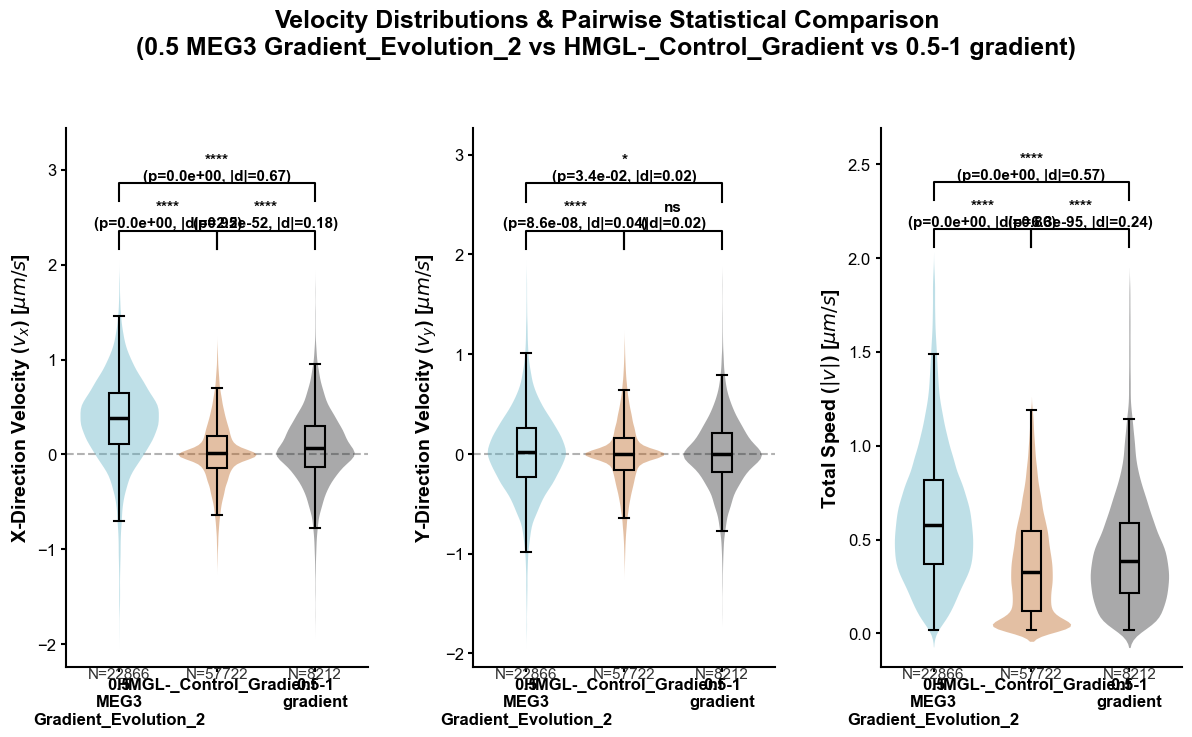

[Success] Statistical report saved to: D:/Research/microfluid_pgl_meg/trackmate_series\Statistical_Report.csv

--- Statistical Analysis Report (Pairwise) ---
   Metric                                              Comparison    N1    N2  U-Statistic      P-Value  Cohen's d  0.5 MEG3 Gradient_Evolution_2 Median  HMGL-_Control_Gradient Median  0.5-1 gradient Median
       Vx 0.5 MEG3 Gradient_Evolution_2 vs HMGL-_Control_Gradient 22866 57722  997433139.0 0.000000e+00   0.950547                              0.381844                       0.010112                    NaN
       Vx         0.5 MEG3 Gradient_Evolution_2 vs 0.5-1 gradient 22866  8212  133031999.0 0.000000e+00   0.669480                              0.381844                            NaN               0.063618
       Vx                HMGL-_Control_Gradient vs 0.5-1 gradient 57722  8212  212426606.5 2.214297e-52  -0.175612                                   NaN                       0.010112               0.063618
       Vy 0.5 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker
from scipy.stats import mannwhitneyu

# ==========================================
# 1. Configuration Parameters (Configuration)
# ==========================================
CONFIG = {
    'speed_factor': 5.0,         # Time divisor for velocity calculation (s)
    'speed_magnitude_range': (0.02, 2.0), # Velocity magnitude filter range (for removing noise)
    'font_family': 'Arial',      # Font (CNS recommends Arial or Helvetica)
    'save_format': 'pdf',        # Required output format: PDF
    'palette': ['#4DBBD5',"#D55E00", "#27292B"], # Classic CNS color scheme (blue, red)

    # Plot aesthetics
    'point_size': 1.5,           # Scatter-point size
    'point_alpha': 0.15,         # Scatter-point opacity
    'velocity_range': (-2.0, 2.0),# Axis reference range

    # Plot downsampling settings (scatter plots only; prevent point overlap and oversized PDFs for large N)
    'max_plot_points': 0,      # Maximum number of scatter points per group (set to None to plot all)

    # [Added] Frame range and reversal settings (global defaults; can be overridden per group)
    'frame_range': (1, 200),   # Default Frame range for plotting/analysis [start, end] (inclusive)
    'reverse': False,          # Whether to reverse the analysis (True: reverse the velocity direction)
}

# Global plotting style settings (CNS Aesthetic)
plt.rcParams['font.family'] = CONFIG['font_family']
plt.rcParams['axes.linewidth'] = 1.5      # Bold axes
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 15

# ==========================================
# 2. Data Processing Module
# ==========================================

def smart_read_csv(file_path, required_keyword):
    """智能读取 CSV 函数：自动尝试前 4 行寻找表头，并统一列名格式。"""
    if not os.path.exists(file_path):
        print(f"Error: File not found -> {file_path}")
        return None

    potential_headers = [0, 1, 2, 3]
    for h in potential_headers:
        try:
            df = pd.read_csv(file_path, header=h)
            clean_columns = [str(c).upper().strip() for c in df.columns]
            if required_keyword.upper() in clean_columns:
                df.columns = clean_columns
                return df
        except Exception:
            continue

    print(f"Error: Could not find column '{required_keyword}' in {os.path.basename(file_path)}.")
    return None


def load_and_process_vector_data(files_dict):
    """提取数据并计算矢量速度，执行基础过滤。

    【新增】支持每组的 Frame 范围筛选（默认 1-200）与速度方向反转。
    files_dict 可选键：
        'frame_range': (start, end)  不写则用 CONFIG['frame_range']
        'reverse'   : True/False      不写则用 CONFIG['reverse']
    """
    exp_name = files_dict['name']
    edges_path = files_dict['edges']
    spots_path = files_dict.get('spots')
    if not spots_path:
        spots_path = edges_path.replace('edges.csv', 'spots.csv')

    # [Added] Frame range and reversal can be set per group (uses global defaults when unset)
    frame_range = files_dict.get('frame_range', CONFIG['frame_range'])
    reverse     = files_dict.get('reverse',     CONFIG['reverse'])
    f_start, f_end = frame_range

    print(f"Processing {exp_name}...  [Frame {f_start}-{f_end}, reverse={reverse}]")

    df_spots = smart_read_csv(spots_path, 'ID')
    if df_spots is None: return None

    if df_spots['ID'].duplicated().any():
        df_spots = df_spots.drop_duplicates(subset=['ID'])

    # [Added] Extract the FRAME column as well (for filtering by Frame range)
    spot_cols = ['ID', 'POSITION_X', 'POSITION_Y']
    has_frame = 'FRAME' in df_spots.columns
    if has_frame:
        spot_cols.append('FRAME')
    spots_subset = df_spots[spot_cols].copy()
    spots_subset['ID'] = spots_subset['ID'].astype(int)
    if has_frame:
        spots_subset['FRAME'] = pd.to_numeric(spots_subset['FRAME'], errors='coerce')

    df_edges = smart_read_csv(edges_path, 'SPOT_SOURCE_ID')
    if df_edges is None: return None

    required_cols = ['SPOT_SOURCE_ID', 'SPOT_TARGET_ID']
    if not all(col in df_edges.columns for col in required_cols):
        print(f"  Error: Edges file missing columns. Found: {df_edges.columns}")
        return None

    df_edges['SPOT_SOURCE_ID'] = df_edges['SPOT_SOURCE_ID'].astype(int)
    df_edges['SPOT_TARGET_ID'] = df_edges['SPOT_TARGET_ID'].astype(int)

    # Merge data (FRAME is the frame containing the source spot)
    merged_df = pd.merge(df_edges, spots_subset, left_on='SPOT_SOURCE_ID', right_on='ID', how='inner')
    merged_df.rename(columns={'POSITION_X': 'SRC_X', 'POSITION_Y': 'SRC_Y'}, inplace=True)
    merged_df.drop(columns=['ID'], inplace=True)

    merged_df = pd.merge(merged_df, spots_subset, left_on='SPOT_TARGET_ID', right_on='ID',
                         how='inner', suffixes=('', '_TGT'))
    merged_df.rename(columns={'POSITION_X': 'TGT_X', 'POSITION_Y': 'TGT_Y'}, inplace=True)
    merged_df.drop(columns=['ID'], inplace=True)

    if merged_df.empty:
        return None

    # [Added] Frame range filter: default 1-200 Frames (inclusive)
    if has_frame:
        merged_df = merged_df[(merged_df['FRAME'] >= f_start) &
                              (merged_df['FRAME'] <= f_end)].copy()
        if merged_df.empty:
            print(f"  Warning: No data in Frame range {f_start}-{f_end} for {exp_name}.")
            return None
    else:
        print("  Warning: No FRAME column found; frame range filtering skipped.")

    # Calculate velocity
    merged_df['Dx'] = merged_df['TGT_X'] - merged_df['SRC_X']
    merged_df['Dy'] = merged_df['TGT_Y'] - merged_df['SRC_Y']
    merged_df['Vx'] = merged_df['Dx'] / CONFIG['speed_factor']
    merged_df['Vy'] = merged_df['Dy'] / CONFIG['speed_factor']

    # [Added] Reverse analysis: reverse the velocity direction when reverse=True
    # (equivalent to playing the frame sequence backward / swapping source and target to reverse displacement direction)
    if reverse:
        merged_df['Vx'] = -merged_df['Vx']
        merged_df['Vy'] = -merged_df['Vy']
        print(f"  -> [Reverse] Velocity direction inverted for {exp_name}.")

    merged_df['Speed_Mag'] = np.sqrt(merged_df['Vx']**2 + merged_df['Vy']**2)

    # [Core: data cleaning] Keep only valid data within this range; all subsequent N calculations are based on this clean data
    vmin, vmax = CONFIG['speed_magnitude_range']
    df_clean = merged_df[(merged_df['Speed_Mag'] >= vmin) &
                         (merged_df['Speed_Mag'] <= vmax)].copy()

    # Add label column
    df_clean['Condition'] = exp_name

    print(f"  -> Processed {len(df_clean)} valid vectors after filtering "
          f"(Frame {f_start}-{f_end}, speed {vmin} to {vmax}).")
    return df_clean

# ==========================================
# 3. Statistical Testing and Core Plotting
# ==========================================

def calculate_cohens_d(x, y):
    """计算效应量 Cohen's d (Effect Size)
    大样本下 P 值极易显著，引入 d 值判断差异的实际物理意义。
    |d| < 0.2 (微小/可忽略), 0.2~0.5 (小), 0.5~0.8 (中), >0.8 (大)
    """
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pool_var = ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof
    if pool_var == 0:
        return 0
    return (np.mean(x) - np.mean(y)) / np.sqrt(pool_var)

def get_significance_stars(p_value):
    """根据P值返回显著性星号"""
    if p_value < 0.0001: return '****'
    elif p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'ns'

def draw_significance_bracket(ax, x1, x2, y_base, h, p_value, cohens_d, fontsize=11):
    """在坐标轴上绘制统计学显著性连线及效应量标注（支持多组分层，y_base 为该层底线高度）"""
    y = y_base
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='black')

    stars = get_significance_stars(p_value)
    if p_value < 0.05:
        text = f"{stars}\n(p={p_value:.1e}, |d|={abs(cohens_d):.2f})"
    else:
        text = f"ns\n(|d|={abs(cohens_d):.2f})"

    ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom',
            color='black', fontsize=fontsize, fontweight='bold')

def assign_tiers(pairs):
    """【新增】将多组两两比较的括号分配到不同层级，避免重叠。
    pairs: [(i, j), ...] 其中 i < j，返回 {pair: tier_index}
    """
    tiers = []  # tiers[t] = list of pairs already placed at this tier
    assignment = {}
    for p in pairs:
        i, j = p
        placed = False
        for t_idx, t_pairs in enumerate(tiers):
            # Add to the tier only if it shares no interval with any existing bracket in that tier
            if all(not (i < b and a < j) for (a, b) in t_pairs):
                t_pairs.append(p)
                assignment[p] = t_idx
                placed = True
                break
        if not placed:
            tiers.append([p])
            assignment[p] = len(tiers) - 1
    return assignment

def plot_statistical_distributions(df, group_col, conditions, save_dir):
    """绘制三大核心指标的统计分布图。

    【新增】支持 ≥2 组：自动对所有组两两进行 Mann-Whitney U 检验 + Cohen's d，
    显著性括号按层级自动排布，避免重叠。
    """
    metrics = [
        ('Vx', r'X-Direction Velocity ($v_x$) [$\mu m/s$]'),
        ('Vy', r'Y-Direction Velocity ($v_y$) [$\mu m/s$]'),
        ('Speed_Mag', r'Total Speed ($|v|$) [$\mu m/s$]')
    ]

    n_conds = len(conditions)
    # [Added] Adapt figure width to the number of groups
    fig, axes = plt.subplots(1, 3, figsize=(3.8 * n_conds + 3, 7))
    plt.subplots_adjust(wspace=0.35)

    # [Added] All pairwise combinations and tier assignment
    pairs = [(i, j) for i in range(n_conds) for j in range(i + 1, n_conds)]
    tier_map = assign_tiers(pairs)
    max_tier = max(tier_map.values()) if pairs else 0

    stats_report = []

    # --- Visual downsampling (stripplot only; prevent point overlap for large N) ---
    scatter_df = df.copy()
    if CONFIG['max_plot_points']:
        sampled_list = []
        for cond in conditions:
            cond_data = df[df[group_col] == cond]
            if len(cond_data) > CONFIG['max_plot_points']:
                sampled_list.append(cond_data.sample(n=CONFIG['max_plot_points'], random_state=42))
            else:
                sampled_list.append(cond_data)
        scatter_df = pd.concat(sampled_list)

    for i, (col, ylabel) in enumerate(metrics):
        ax = axes[i]

        # Extract data for each group (full filtered clean data for rigorous statistics)
        group_data = {cond: df[df[group_col] == cond][col].dropna() for cond in conditions}
        ns = {cond: len(group_data[cond]) for cond in conditions}

        # --- [Added] Pairwise Statistical Tests and Effect Sizes ---
        pair_results = []
        for (a, b) in pairs:
            data_a = group_data[conditions[a]]
            data_b = group_data[conditions[b]]
            stat, p_val = mannwhitneyu(data_a, data_b, alternative='two-sided')
            d_val = calculate_cohens_d(data_a, data_b)
            pair_results.append({'Pair': (a, b), 'P': p_val, 'd': d_val})
            stats_report.append({
                'Metric': col,
                'Comparison': f'{conditions[a]} vs {conditions[b]}',
                'N1': len(data_a), 'N2': len(data_b),
                'U-Statistic': stat, 'P-Value': p_val, "Cohen's d": d_val,
                f'{conditions[a]} Median': data_a.median(),
                f'{conditions[b]} Median': data_b.median(),
            })

        # --- Plotting: 1. Violin Plot (full density distribution) ---
        sns.violinplot(data=df, x=group_col, y=col, order=conditions, palette=CONFIG['palette'],
                       inner=None, linewidth=0, ax=ax, alpha=0.5, zorder=1)
        for collection in ax.collections:
            collection.set_alpha(0.4)

        # --- Plotting: 2. Scatter Plot (downsampled data; uncomment when needed) ---
        # sns.stripplot(data=scatter_df, x=group_col, y=col, order=conditions,
        #               palette=CONFIG['palette'], jitter=0.2, size=CONFIG['point_size'],
        #               alpha=CONFIG['point_alpha'], edgecolor='none', ax=ax, zorder=2)

        # --- Plotting: 3. Box Plot (full quartiles and median) ---
        sns.boxplot(data=df, x=group_col, y=col, order=conditions, width=0.2,
                    boxprops={'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5},
                    whiskerprops={'color': 'black', 'linewidth': 1.5},
                    capprops={'color': 'black', 'linewidth': 1.5},
                    medianprops={'color': 'black', 'linewidth': 2.5},
                    showfliers=False, ax=ax, zorder=3)

        # Auxiliary lines
        if col in ['Vx', 'Vy']:
            ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.6, zorder=0)

        # Set axis labels
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_xlabel('')
        labels = [c.replace(' ', '\n') for c in conditions]
        ax.set_xticklabels(labels, fontweight='bold')

        # --- [Added] Reserve space at the top (based on the maximum number of tiers), then annotate N ---
        data_max = df[col].max()
        data_min = df[col].min()
        span = max(data_max - data_min, 1e-9)          # Prevent division by zero when all values are constant
        tier_spacing = span * 0.13
        tier_h = span * 0.05
        y_base = data_max + span * 0.06
        y_top = y_base + max_tier * tier_spacing + 4 * tier_h
        ax.set_ylim(ax.get_ylim()[0], y_top)

        # [Added] Annotate the true total filtered N below each group
        for idx, cond in enumerate(conditions):
            ax.text(idx, ax.get_ylim()[0], f'N={ns[cond]}', ha='center', va='top',
                    fontsize=11, color='#333')

        # --- [Added] Pairwise-test brackets (drawn in tiers to avoid overlap) ---
        fontsize = 11 if n_conds <= 3 else 8
        for (a, b) in pairs:
            res = next(r for r in pair_results if r['Pair'] == (a, b))
            tier = tier_map[(a, b)]
            draw_significance_bracket(ax, a, b,
                                      y_base + tier * tier_spacing, tier_h,
                                      res['P'], res['d'], fontsize=fontsize)

        # Remove the top and right spines
        sns.despine(ax=ax, top=True, right=True)

    # Adjust the overall layout
    fig.suptitle(f'Velocity Distributions & Pairwise Statistical Comparison\n'
                 f"({' vs '.join(conditions)})",
                 fontsize=18, fontweight='bold', y=1.05)

    # 1. Save figure (using the format specified in CONFIG)
    out_path = os.path.join(save_dir, f"Velocity_Comparison_Stats.{CONFIG['save_format']}")
    plt.savefig(out_path, format=CONFIG['save_format'], dpi=600,
                bbox_inches='tight', transparent=True)
    print(f"\n[Success] Statistical plot saved to: {out_path}")
    plt.show()

    # 2. Save statistical test report
    stats_df = pd.DataFrame(stats_report)
    report_path = os.path.join(save_dir, "Statistical_Report.csv")
    try:
        stats_df.to_csv(report_path, index=False, encoding='utf-8-sig')
        print(f"[Success] Statistical report saved to: {report_path}")
    except Exception as e:
        print(f"[Warning] Failed to save report CSV. Error: {e}")

    # Print statistical test report
    print("\n--- Statistical Analysis Report (Pairwise) ---")
    print(stats_df.to_string(index=False))

    # Print Mean ± SD (N=xxx) results
    print("\n--- Descriptive Statistics: Mean ± SD (N) ---")
    for col, ylabel in metrics:
        print(f"  {col}:")
        for cond in conditions:
            data = df[df[group_col] == cond][col].dropna()
            print(f"    {cond}: {data.mean():.6f} ± {data.std():.6f} (N={len(data)})")

    # Brief interpretation
    print("\n* Note: Cohen's d indicates the effect size (standardized difference).")
    print("  |d| < 0.2: Trivial | 0.2~0.5: Small | 0.5~0.8: Medium | > 0.8: Large")

# ==========================================
# 4. Main Program
# ==========================================

if __name__ == "__main__":
    base_dir = "D:/Research/microfluid_pgl_meg/trackmate_series"

    experiments = [
        {
            'name': '0.5 MEG3 Gradient_Evolution_2',
            'edges': os.path.join(base_dir, 'mf_fl1_edges.csv'),
            'spots': os.path.join(base_dir, 'mf_fl1_spots.csv'),
            'frame_range': (1, 200),   # [Added] Customize the Frame range per group (default 1-200)
            'reverse': False,          # [Added] Whether to reverse the analysis for this group
        },
        {
             'name': 'HMGL-_Control_Gradient',
             'spots': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_spots.csv'),
             'edges': os.path.join(base_dir, 'HMGL-+4.5pgl_flowcell_edges.csv'),
             'frame_range': (1, 200),
             'reverse': False,
        },
        #{
            #'name': 'Delta16_Gradient',
            #'spots': os.path.join(base_dir, 'mf_delta_1_spots.csv'),
            #'edges': os.path.join(base_dir, 'mf_delta_1_edges.csv'),
            #'frame_range': (1, 200),
            #'reverse': False,
        #},
        {
            'name': '0.5-1 gradient',
            'spots': os.path.join(base_dir, '1_0.5FL_spots.csv'),
            'edges': os.path.join(base_dir, '1_0.5FL_edges.csv'),
            'frame_range': (1, 200),
            'reverse': True,
        },
    ]

    all_data = []
    condition_names = []

    for exp in experiments:
        df_result = load_and_process_vector_data(exp)
        if df_result is not None:
            all_data.append(df_result)
            condition_names.append(exp['name'])

    # [Added] Support ≥2 groups (for 2 groups, this is the original single pairwise comparison; for multiple groups, automatically run pairwise tests)
    if len(all_data) >= 2:
        final_df = pd.concat(all_data, ignore_index=True)
        export_df = final_df[['Condition', 'FRAME', 'SRC_X', 'SRC_Y', 'TGT_X', 'TGT_Y',
                              'Vx', 'Vy', 'Speed_Mag']]

        excel_path = os.path.join(base_dir, "Velocity_Comparison_Data.xlsx")
        try:
            export_df.to_excel(excel_path, index=False)
            print(f"[Success] Data exported to Excel for further checking: {excel_path}")
        except Exception as e:
            print(f"[Warning] Failed to save Excel file (Make sure 'openpyxl' is installed). Error: {e}")

        plot_statistical_distributions(final_df, 'Condition', condition_names, base_dir)

    else:
        print("\nError: Data processing failed. Need at least 2 valid groups "
              "for statistical comparison.")

下面按照之前的方案绘制MSD分析的图表。

形式：双对数坐标系 ($\log-\log$ Plot)。X轴为 $\Delta t$，Y轴为 MSD。

内容：绘制曲线并进行幂律拟合 $MSD \propto \tau^\alpha$。

MSD分析采用系综平均的方法，先对每一条轨迹单独计算时间平均MSD (tMSD)，然后将所有轨迹的tMSD曲线进行系综平均（取平均值），最后对这条总的平均曲线拟合得到指数 $\alpha$
对每条轨迹，处在相同轨迹中的点spots文件的TRACK_ID列中是相同的。
起始点是POSITION_T一列数值最小的点，结束点是POSITION_T一列数值最大的点。
以POSITION_T为排序的参考可以得到这条TRACK所有点的有序序列。
对每条轨迹分别计算每个点相较起始点的位移平方和(坐标在POSITION_X和POSITION_Y列)和时间差(POSITION_T列与起始点的差值)
即得到该轨迹的tMSD数据。
以合理的方式进行系综平均，得到该组实验中所有轨迹的平均MSD曲线并对其进行幂律拟合，得到指数 $\alpha$。

精心设计布局和配色方案保证高度美观协调，可拓展性强（能够在此基础上方便的加上对照组和其他实验条件的结果），对于表格中的NaN以0代替。POSITION_T列的数据均乘以5，单位转换为秒。
POSITION_X和POSITION_Y列的数据单位为微米。


方法 A：系综平均 MSD (Ensemble-averaged MSD, eMSD)这对应于你提到的“对每个时间间隔下的 edge 做并”。

计算方式： 设定一个绝对时间点 $t$（例如实验开始后的第 10 秒），选取该时刻所有存在的粒子，计算它们在 $t$ 到 $t+\tau$ 之间的位移，然后取平均。公式：$$\langle r^2(\tau) \rangle = \frac{1}{N} \sum_{i=1}^{N} [r_i(t+\tau) - r_i(t)]^2$$

适用场景：系统是非稳态的（Non-stationary），例如粒子性质随时间老化。你需要研究所有粒子在特定时刻的集体行为。

缺点： 需要极大的粒子数量 $N$ 才能获得光滑的曲线。

Multiple groups MSD comparison

[*] Processing Group: MEG-3 Gradient
    [Success] Alpha = 1.614 ± 0.015, Tracks = 737
[*] Processing Group: HMGL- Control Gradient
    [Success] Alpha = 0.821 ± 0.050, Tracks = 4700
[*] Plot saved to: D:/Research/microfluid_pgl_meg/Trackmate_series\MSD_comparative_msd_analysis_20260324_111242.svg


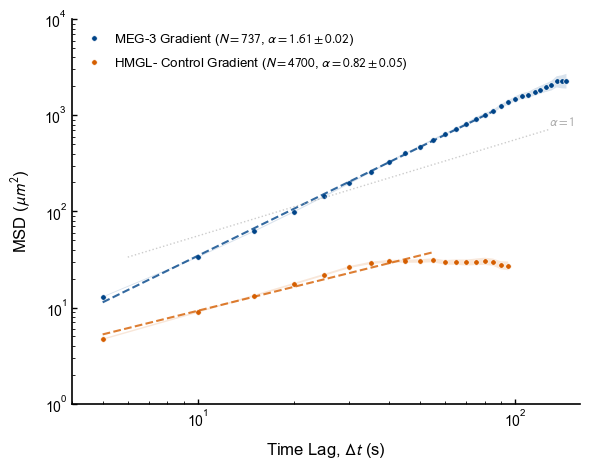

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os
import time
from datetime import datetime

# ==========================================
# 1. GLOBAL CONFIGURATION (Nature/CNS Style)
# ==========================================
STYLE_CONFIG = {
    'font_family': 'Arial',
    'axes_linewidth': 1.2,
    'tick_width': 1.0,
    'dpi': 600,
    'save_format': 'svg',  # Changed to .svg as requested
    'palette': ['#004488', '#D55E00', '#009E73', '#CC79A7', '#56B4E9'], 
    'alpha_fill': 0.15,
    'fit_range': 0.25,      # Default: use first 25% of data points for power-law fitting
}

# Apply global matplotlib settings
plt.rcParams.update({
    'font.family': STYLE_CONFIG['font_family'],
    'axes.linewidth': STYLE_CONFIG['axes_linewidth'],
    'xtick.major.width': STYLE_CONFIG['tick_width'],
    'ytick.major.width': STYLE_CONFIG['tick_width'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': False,      # Disable top ticks
    'ytick.right': False,    # Disable right ticks
    'mathtext.fontset': 'stixsans', # Use sans-serif math font to match Arial
    'pdf.fonttype': 42,      
    'ps.fonttype': 42
})

class MSDAnalyzer:
    def __init__(self, time_interval=1.0, pixel_size=1.0, min_track_len=10):
        """
        Initialize the analyzer.
        :param time_interval: Time between frames (seconds).
        :param pixel_size: Size of one pixel (microns).
        :param min_track_len: Minimum points required for a valid track.
        """
        self.dt = time_interval
        self.px = pixel_size
        self.min_len = min_track_len
        self.datasets = {} # Stores results for multiple groups

    def load_and_process(self, group_name, filepath, fit_range=None, max_lag_time=None):
        """
        Load TrackMate spots and compute time-lagged MSD for all trajectories.
        """
        print(f"[*] Processing Group: {group_name}")
        current_fit_range = fit_range if fit_range is not None else STYLE_CONFIG['fit_range']
        
        try:
            try:
                df = pd.read_csv(filepath)
                if 'TRACK_ID' not in df.columns:
                    df = pd.read_csv(filepath, skiprows=3)
            except Exception:
                print(f"    [Error] Could not parse {filepath}")
                return False

            df.columns = [str(c).upper().strip() for c in df.columns]
            
            # Unit Conversion
            df['X_UM'] = df['POSITION_X'] * self.px
            df['Y_UM'] = df['POSITION_Y'] * self.px
            time_col = 'FRAME' if 'FRAME' in df.columns else 'POSITION_T'
            df['T_SEC'] = df[time_col] * self.dt

            all_msds = []
            grouped = df.groupby('TRACK_ID')

            for tid, track in grouped:
                if len(track) < self.min_len:
                    continue
                
                track = track.sort_values('T_SEC')
                x = track['X_UM'].values
                y = track['Y_UM'].values
                
                n_points = len(track)
                # Max lag is limited by track length or user-specified max_lag_time
                max_lag_steps = n_points // 2 
                if max_lag_time:
                    max_lag_steps = min(max_lag_steps, int(max_lag_time / self.dt))

                lags = np.arange(1, max_lag_steps)
                
                track_res = []
                for lag in lags:
                    dx = x[lag:] - x[:-lag]
                    dy = y[lag:] - y[:-lag]
                    sq_dist = dx**2 + dy**2
                    track_res.append([lag * self.dt, np.mean(sq_dist)])
                
                all_msds.append(pd.DataFrame(track_res, columns=['tau', 'msd']))

            if not all_msds:
                print(f"    [Warning] No valid tracks found in {group_name}")
                return False

            master_df = pd.concat(all_msds)
            summary = master_df.groupby('tau')['msd'].agg(['mean', 'sem', 'count']).reset_index()
            summary.rename(columns={'mean': 'MSD', 'sem': 'SEM', 'count': 'N'}, inplace=True)
            
            # Fitting: MSD = K * t^alpha
            fit_mask = (summary['tau'] > 0) & (summary['tau'] < summary['tau'].max() * current_fit_range)
            fit_df = summary[fit_mask]
            
            alpha, alpha_err, K = np.nan, np.nan, np.nan
            fit_curve = None
            if len(fit_df) > 2:
                log_t = np.log10(fit_df['tau'].values)
                log_m = np.log10(fit_df['MSD'].values)
                
                try:
                    # Use cov=True to obtain the covariance matrix for standard error calculation
                    p, V = np.polyfit(log_t, log_m, 1, cov=True)
                    alpha = p[0]
                    alpha_err = np.sqrt(V[0][0]) # V[0][0] is the variance of the slope (alpha)
                    K = 10**p[1]
                    fit_curve = (fit_df['tau'].values, K * (fit_df['tau'].values ** alpha))
                except np.linalg.LinAlgError:
                    # Fallback handling if covariance-matrix calculation fails
                    p = np.polyfit(log_t, log_m, 1)
                    alpha = p[0]
                    K = 10**p[1]
                    fit_curve = (fit_df['tau'].values, K * (fit_df['tau'].values ** alpha))

            self.datasets[group_name] = {
                'data': summary,
                'alpha': alpha,
                'alpha_err': alpha_err,
                'fit_curve': fit_curve,
                'n_tracks': len(grouped),
                'max_display_lag': max_lag_time
            }
            print(f"    [Success] Alpha = {alpha:.3f} ± {alpha_err:.3f}, Tracks = {len(grouped)}")
            return True

        except Exception as e:
            print(f"    [Critical Error] {e}")
            return False

    def plot_multi_group(self, title="Ensemble MSD Analysis", 
                        x_range=(None, None), y_range=(None, None), 
                        save_dir="."):
        """
        Generate a publication-quality log-log plot for all loaded datasets.
        """
        if not self.datasets:
            print("[Error] No data to plot.")
            return

        fig, ax = plt.subplots(figsize=(6.0, 4.8)) # Make it slightly wider to leave room for the legend
        
        for i, (name, res) in enumerate(self.datasets.items()):
            df = res['data']
            # Apply individual group data limit if specified
            if res['max_display_lag']:
                df = df[df['tau'] <= res['max_display_lag']]
                
            color = STYLE_CONFIG['palette'][i % len(STYLE_CONFIG['palette'])]
            
            # 1. Shaded Error Band (SEM)
            ax.fill_between(df['tau'], df['MSD'] - df['SEM'], df['MSD'] + df['SEM'],
                            color=color, alpha=STYLE_CONFIG['alpha_fill'], edgecolor='none')
            
            # 2. Main Data Line & Updated Legend Label
            if np.isnan(res['alpha_err']):
                label_str = f"{name} ($N={res['n_tracks']}$, $\\alpha={res['alpha']:.2f}$)"
            else:
                label_str = f"{name} ($N={res['n_tracks']}$, $\\alpha={res['alpha']:.2f} \pm {res['alpha_err']:.2f}$)"
                
            ax.loglog(df['tau'], df['MSD'], 'o', color=color, markersize=4, 
                      markeredgewidth=0.5, markeredgecolor='white',
                      label=label_str)
            
            # 3. Individual Fit Line (Dashed)
            if res['fit_curve'] is not None:
                fx, fy = res['fit_curve']
                ax.loglog(fx, fy, '--', color=color, linewidth=1.5, alpha=0.8)

        # Reference lines
        self._add_reference_slopes(ax, x_range)

        # Labels and Scaling
        ax.set_xlabel(r'Time Lag, $\Delta t$ (s)', fontsize=12, labelpad=8, fontname='Arial')
        ax.set_ylabel(r'MSD ($\mu m^2$)', fontsize=12, labelpad=8, fontname='Arial')
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        
        # Legend (font adjusted slightly to fit long labels)
        ax.legend(frameon=False, loc='upper left', fontsize=9.5, handlelength=1.5)
        
        # Fine-tuning axes: Completely remove top and right spines and ticks
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='both', top=False, right=False, labelsize=10)
        
        plt.tight_layout()

        # Adaptive Filename (Unique Timestamp)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        safe_title = title.replace(" ", "_").lower()
        filename = f"MSD_{safe_title}_{timestamp}.{STYLE_CONFIG['save_format']}"
        save_path = os.path.join(save_dir, filename)
        
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            
        plt.savefig(save_path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight')
        print(f"[*] Plot saved to: {save_path}")
        plt.show()

    def _add_reference_slopes(self, ax, x_range):
        """Helper to add alpha=1 guide line."""
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        start_x = x_range[0] if x_range[0] else xmin
        end_x = x_range[1] if x_range[1] else xmax
        
        ref_x = np.logspace(np.log10(start_x * 1.5), np.log10(end_x * 0.8), 10)
        
        # Calculate baseline y-position (avoiding log errors)
        y_anchor = ymin * 10 if not (np.isnan(ymin) or ymin <= 0) else 1.0
        ref_y1 = y_anchor * (ref_x / ref_x[0])**1
        
        ax.loglog(ref_x, ref_y1, ':', color='#AAAAAA', linewidth=1.0, alpha=0.6)
        ax.text(ref_x[-1], ref_y1[-1], '$\\alpha=1$', fontsize=9, color='#AAAAAA', 
                va='bottom', ha='left', fontname='Arial')

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    # --- 1. SETUP ---
    analyzer = MSDAnalyzer(
        time_interval = 5.0,   # Seconds per frame
        pixel_size    = 1.0,   # Micron per pixel
        min_track_len = 15   
    )

    base_path = "D:/Research/microfluid_pgl_meg/Trackmate_series"
    
    # --- 2. DATA LOADING & INDIVIDUAL RANGES ---
    experiments = [
        {
            'label': 'MEG-3 Gradient',
            'path': os.path.join(base_path, 'mf_fl1_spots.csv'),
            'fit_range': 0.6,       # Use first 60% for fitting
            'max_lag': 150          # Show up to 150s
        },
        {
            'label': 'HMGL- Control Gradient',
            'path': os.path.join(base_path, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            'fit_range': 0.6,       # Use first 60% for fitting
            'max_lag': 100          # Show up to 100s
        },
        {
            
        }
    ]

    for exp in experiments:
        if os.path.exists(exp['path']):
            analyzer.load_and_process(
                exp['label'], 
                exp['path'], 
                fit_range=exp.get('fit_range'),
                max_lag_time=exp.get('max_lag')
            )
        else:
            print(f"[Skip] File not found: {exp['path']}")

    # --- 3. VISUALIZATION ---
    analyzer.plot_multi_group(
        title   = "Comparative MSD Analysis",
        x_range = (4, 160),    
        y_range = (1, 10000), 
        save_dir = base_path
    )

<>:199: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:199: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\1\AppData\Local\Temp\ipykernel_32016\4114379478.py:199: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  label_str = f"{name} ($N={res['n_tracks']}$, $\\alpha={res['alpha']:.2f} \pm {res['alpha_err']:.2f}$)"


[*] Processing Group: MEG-3 Gradient
    [Frame Range] Frames 1-200 → kept 23645/23689 rows
    [Success] Alpha = 1.614 ± 0.015, Tracks = 737, Frames = 1-200
[*] Processing Group: HMGL- Control Gradient
    [Frame Range] Frames 1-200 → kept 68606/68862 rows
    [Success] Alpha = 0.818 ± 0.051, Tracks = 1173, Frames = 1-200
[*] Processing Group: 0.5-1 gradient+5PGL
    [Frame Range] Frames 15-50 → kept 6001/9358 rows
    [Success] Alpha = 0.995 ± 0.017, Tracks = 120, Frames = 15-50
[*] Plot saved to: D:/Research/microfluid_pgl_meg/Trackmate_series\MSD_comparative_msd_analysis_20260805_232408.svg


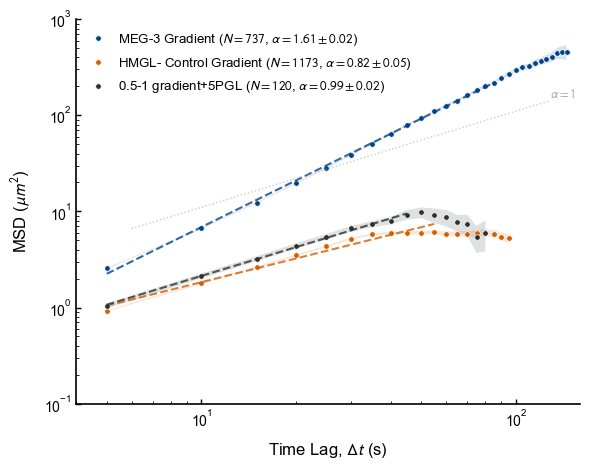

[Error] Failed to export Excel file. (Do you have openpyxl installed? 'pip install openpyxl'). Error details: No module named 'openpyxl'


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os
import time
from datetime import datetime

# ==========================================
# 1. GLOBAL CONFIGURATION (Nature/CNS Style)
# ==========================================
STYLE_CONFIG = {
    'font_family': 'Arial',
    'axes_linewidth': 1.2,
    'tick_width': 1.0,
    'dpi': 600,
    'save_format': 'svg',  # Changed to .svg as requested
    'palette': ['#004488', '#D55E00', "#2E302F", '#CC79A7', '#56B4E9'], 
    'alpha_fill': 0.15,
    'fit_range': 0.25,      # Default: use first 25% of data points for power-law fitting
}

# Apply global matplotlib settings
plt.rcParams.update({
    'font.family': STYLE_CONFIG['font_family'],
    'axes.linewidth': STYLE_CONFIG['axes_linewidth'],
    'xtick.major.width': STYLE_CONFIG['tick_width'],
    'ytick.major.width': STYLE_CONFIG['tick_width'],
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': False,      # Disable top ticks
    'ytick.right': False,    # Disable right ticks
    'mathtext.fontset': 'stixsans', # Use sans-serif math font to match Arial
    'pdf.fonttype': 42,      
    'ps.fonttype': 42
})

class MSDAnalyzer:
    def __init__(self, time_interval=1.0, pixel_size=1.0, min_track_len=10):
        """
        Initialize the analyzer.
        :param time_interval: Time between frames (seconds).
        :param pixel_size: Size of one pixel (microns).
        :param min_track_len: Minimum points required for a valid track.
        """
        self.dt = time_interval
        self.px = pixel_size
        self.min_len = min_track_len
        self.datasets = {} # Stores results for multiple groups

    def load_and_process(self, group_name, filepath, fit_range=None, max_lag_time=None,
                         frame_range=(1, 200)):
        """
        Load TrackMate spots and compute time-lagged MSD for all trajectories.

        :param frame_range: tuple (frame_min, frame_max) — only frames in this
                            range are used for the MSD analysis. Default (1, 200).
        """
        print(f"[*] Processing Group: {group_name}")
        current_fit_range = fit_range if fit_range is not None else STYLE_CONFIG['fit_range']
        
        try:
            try:
                df = pd.read_csv(filepath)
                if 'TRACK_ID' not in df.columns:
                    df = pd.read_csv(filepath, skiprows=3)
            except Exception:
                print(f"    [Error] Could not parse {filepath}")
                return False

            df.columns = [str(c).upper().strip() for c in df.columns]
            
            # --- NEW: Frame range filtering (default 1-200) ---
            frame_min, frame_max = frame_range
            if 'FRAME' in df.columns:
                n_before = len(df)
                df = df[(df['FRAME'] >= frame_min) & (df['FRAME'] <= frame_max)]
                print(f"    [Frame Range] Frames {frame_min}-{frame_max} → kept {len(df)}/{n_before} rows")
            else:
                print(f"    [Warning] No 'FRAME' column; frame_range {frame_range} NOT applied")
            
            # Unit Conversion
            df['X_UM'] = df['POSITION_X'] * self.px
            df['Y_UM'] = df['POSITION_Y'] * self.px
            time_col = 'FRAME' if 'FRAME' in df.columns else 'POSITION_T'
            df['T_SEC'] = df[time_col] * self.dt

            all_msds = []
            grouped = df.groupby('TRACK_ID')

            for tid, track in grouped:
                if len(track) < self.min_len:
                    continue
                
                track = track.sort_values('T_SEC')
                x = track['X_UM'].values
                y = track['Y_UM'].values
                
                n_points = len(track)
                # Max lag is limited by track length or user-specified max_lag_time
                max_lag_steps = n_points // 2 
                if max_lag_time:
                    max_lag_steps = min(max_lag_steps, int(max_lag_time / self.dt))

                lags = np.arange(1, max_lag_steps)
                
                track_res = []
                for lag in lags:
                    dx = x[lag:] - x[:-lag]
                    dy = y[lag:] - y[:-lag]
                    sq_dist = dx**2 + dy**2
                    track_res.append([lag * self.dt, np.mean(sq_dist)])
                
                all_msds.append(pd.DataFrame(track_res, columns=['tau', 'msd']))

            if not all_msds:
                print(f"    [Warning] No valid tracks found in {group_name}")
                return False

            master_df = pd.concat(all_msds)
            
            # --- MODIFIED: Added 'std' for standard deviation ---
            summary = master_df.groupby('tau')['msd'].agg(['mean', 'std', 'sem', 'count']).reset_index()
            summary.rename(columns={'mean': 'MSD', 'std': 'SD', 'sem': 'SEM', 'count': 'N'}, inplace=True)
            
            # Fitting: MSD = K * t^alpha
            fit_mask = (summary['tau'] > 0) & (summary['tau'] < summary['tau'].max() * current_fit_range)
            fit_df = summary[fit_mask]
            
            alpha, alpha_err, K = np.nan, np.nan, np.nan
            fit_curve = None
            if len(fit_df) > 2:
                log_t = np.log10(fit_df['tau'].values)
                log_m = np.log10(fit_df['MSD'].values)
                
                try:
                    # Use cov=True to obtain the covariance matrix for standard error calculation
                    p, V = np.polyfit(log_t, log_m, 1, cov=True)
                    alpha = p[0]
                    alpha_err = np.sqrt(V[0][0]) # V[0][0] is the variance of the slope (alpha)
                    K = 10**p[1]
                    fit_curve = (fit_df['tau'].values, K * (fit_df['tau'].values ** alpha))
                except np.linalg.LinAlgError:
                    # Fallback handling if covariance-matrix calculation fails
                    p = np.polyfit(log_t, log_m, 1)
                    alpha = p[0]
                    K = 10**p[1]
                    fit_curve = (fit_df['tau'].values, K * (fit_df['tau'].values ** alpha))

            # --- BUG FIX: Use len(all_msds) which represents valid tracks after min_len filtering ---
            valid_tracks_count = len(all_msds)
            
            self.datasets[group_name] = {
                'data': summary,
                'alpha': alpha,
                'alpha_err': alpha_err,
                'fit_curve': fit_curve,
                'n_tracks': valid_tracks_count, # Corrected track count
                'max_display_lag': max_lag_time,
                'frame_range': frame_range,     # ← NEW: store frame range used
            }
            print(f"    [Success] Alpha = {alpha:.3f} ± {alpha_err:.3f}, "
                  f"Tracks = {valid_tracks_count}, Frames = {frame_min}-{frame_max}")
            return True

        except Exception as e:
            print(f"    [Critical Error] {e}")
            return False

    def plot_multi_group(self, title="Ensemble MSD Analysis", 
                        x_range=(None, None), y_range=(None, None), 
                        save_dir="."):
        """
        Generate a publication-quality log-log plot for all loaded datasets.
        """
        if not self.datasets:
            print("[Error] No data to plot.")
            return

        fig, ax = plt.subplots(figsize=(6.0, 4.8)) # Make it slightly wider to leave room for the legend
        
        for i, (name, res) in enumerate(self.datasets.items()):
            df = res['data']
            # Apply individual group data limit if specified
            if res['max_display_lag']:
                df = df[df['tau'] <= res['max_display_lag']]
                
            color = STYLE_CONFIG['palette'][i % len(STYLE_CONFIG['palette'])]
            
            # 1. Shaded Error Band (SEM)
            ax.fill_between(df['tau'], df['MSD'] - df['SEM'], df['MSD'] + df['SEM'],
                            color=color, alpha=STYLE_CONFIG['alpha_fill'], edgecolor='none')
            
            # 2. Main Data Line & Updated Legend Label
            if np.isnan(res['alpha_err']):
                label_str = f"{name} ($N={res['n_tracks']}$, $\\alpha={res['alpha']:.2f}$)"
            else:
                label_str = f"{name} ($N={res['n_tracks']}$, $\\alpha={res['alpha']:.2f} \pm {res['alpha_err']:.2f}$)"
                
            ax.loglog(df['tau'], df['MSD'], 'o', color=color, markersize=4, 
                      markeredgewidth=0.5, markeredgecolor='white',
                      label=label_str)
            
            # 3. Individual Fit Line (Dashed)
            if res['fit_curve'] is not None:
                fx, fy = res['fit_curve']
                ax.loglog(fx, fy, '--', color=color, linewidth=1.5, alpha=0.8)

        # Reference lines
        self._add_reference_slopes(ax, x_range)

        # Labels and Scaling
        ax.set_xlabel(r'Time Lag, $\Delta t$ (s)', fontsize=12, labelpad=8, fontname='Arial')
        ax.set_ylabel(r'MSD ($\mu m^2$)', fontsize=12, labelpad=8, fontname='Arial')
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        
        # Legend (font adjusted slightly to fit long labels)
        ax.legend(frameon=False, loc='upper left', fontsize=9.5, handlelength=1.5)
        
        # Fine-tuning axes: Completely remove top and right spines and ticks
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='both', top=False, right=False, labelsize=10)
        
        plt.tight_layout()

        # Adaptive Filename (Unique Timestamp)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        safe_title = title.replace(" ", "_").lower()
        filename = f"MSD_{safe_title}_{timestamp}.{STYLE_CONFIG['save_format']}"
        save_path = os.path.join(save_dir, filename)
        
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)
            
        plt.savefig(save_path, dpi=STYLE_CONFIG['dpi'], bbox_inches='tight')
        print(f"[*] Plot saved to: {save_path}")
        plt.show()

    def _add_reference_slopes(self, ax, x_range):
        """Helper to add alpha=1 guide line."""
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        
        start_x = x_range[0] if x_range[0] else xmin
        end_x = x_range[1] if x_range[1] else xmax
        
        ref_x = np.logspace(np.log10(start_x * 1.5), np.log10(end_x * 0.8), 10)
        
        # Calculate baseline y-position (avoiding log errors)
        y_anchor = ymin * 10 if not (np.isnan(ymin) or ymin <= 0) else 1.0
        ref_y1 = y_anchor * (ref_x / ref_x[0])**1
        
        ax.loglog(ref_x, ref_y1, ':', color='#AAAAAA', linewidth=1.0, alpha=0.6)
        ax.text(ref_x[-1], ref_y1[-1], '$\\alpha=1$', fontsize=9, color='#AAAAAA', 
                va='bottom', ha='left', fontname='Arial')

    # --- NEW METHOD: Export to Excel ---
    def export_to_excel(self, title="MSD_Export", save_dir="."):
        """
        Exports the filtered, reproducible plotting data into an Excel spreadsheet.
        Creates a separate sheet for each experimental group, plus a Meta sheet
        recording the frame range and fitting parameters used.
        """
        if not self.datasets:
            print("[Error] No data to export.")
            return

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        safe_title = title.replace(" ", "_").lower()
        filename = f"{safe_title}_{timestamp}.xlsx"
        save_path = os.path.join(save_dir, filename)

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        # Ensure openpyxl or generic pandas to_excel engine works
        try:
            with pd.ExcelWriter(save_path) as writer:
                # --- NEW: Write metadata sheet first (frame range per group) ---
                meta_rows = [
                    {'Group': name,
                     'Frame Range': f"{res.get('frame_range', (1, 200))[0]}-{res.get('frame_range', (1, 200))[1]}",
                     'Total N (Tracks)': res['n_tracks'],
                     'Alpha': res['alpha'],
                     'Alpha Err': res['alpha_err'],
                     'Max Lag (s)': res['max_display_lag']}
                    for name, res in self.datasets.items()
                ]
                pd.DataFrame(meta_rows).to_excel(writer, sheet_name='Meta', index=False)

                for name, res in self.datasets.items():
                    df = res['data'].copy()
                    
                    # 1. Apply the exact same data limit as plotted
                    if res['max_display_lag']:
                        df = df[df['tau'] <= res['max_display_lag']]
                    
                    # 2. Extract strictly necessary columns for plot reproduction
                    export_df = df[['tau', 'N', 'MSD', 'SD', 'SEM']].copy()
                    
                    # --- ADDED TO UNIFY PLOT AND EXCEL ---
                    # Insert a column showing the total number of tracks (N in the legend)
                    export_df.insert(1, 'Total_N', res['n_tracks'])
                    
                    # 3. Rename clearly for the end-user
                    export_df.rename(columns={
                        'tau': 'Delta t (s)',
                        'Total_N': 'Total N (Plot Legend)',
                        'N': 'Contributing N (at lag)',
                        'MSD': 'Mean MSD (um^2)',
                        'SD': 'SD',
                        'SEM': 'SE'
                    }, inplace=True)
                    
                    # Excel sheet names are strictly capped at 31 characters
                    sheet_name = str(name)[:31]
                    
                    # Write to Excel
                    export_df.to_excel(writer, sheet_name=sheet_name, index=False)
                    
            print(f"[*] Plotting data successfully exported to Excel: {save_path}")
        except Exception as e:
            print(f"[Error] Failed to export Excel file. (Do you have openpyxl installed? 'pip install openpyxl'). Error details: {e}")

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    # --- 1. SETUP ---
    analyzer = MSDAnalyzer(
        time_interval = 5.0,   # Seconds per frame
        pixel_size    = 0.445,   # Micron per pixel
        min_track_len = 15   
    )

    base_path = "D:/Research/microfluid_pgl_meg/Trackmate_series"
    
    # --- 2. DATA LOADING & INDIVIDUAL RANGES ---
    experiments = [
        {
            'label': 'MEG-3 Gradient',
            'path': os.path.join(base_path, 'mf_fl1_spots.csv'),
            'fit_range': 0.6,       # Use first 60% for fitting
            'max_lag': 150,         # Show up to 150s
            'frame_range': (1, 200) # ← NEW: default frame range
        },
        {
            'label': 'HMGL- Control Gradient',
            'path': os.path.join(base_path, 'HMGL-+4.5pgl_flowcell_spots.csv'),
            'fit_range': 0.6,       # Use first 60% for fitting
            'max_lag': 100,         # Show up to 100s
            'frame_range': (1, 200) # ← NEW: example of per-group override
        },
        #{
            #'label': 'Delta16_Gradient',
            #'path': os.path.join(base_path, 'mf_delta_1_spots.csv'),
            #'fit_range': 0.6,
            #'max_lag': 100,
            #'frame_range': (1, 200) # ← NEW
        #},
        {
            'label': '0.5-1 gradient+5PGL',
            'path': os.path.join(base_path, '1_0.5FL_spots.csv'),
            'fit_range': 0.6,
            'max_lag': 150,
            'frame_range': (15,50) # ← NEW
        }
    ]

    for exp in experiments:
        if os.path.exists(exp['path']):
            analyzer.load_and_process(
                exp['label'], 
                exp['path'], 
                fit_range=exp.get('fit_range'),
                max_lag_time=exp.get('max_lag'),
                frame_range=exp.get('frame_range', (1, 200))  # ← NEW: pass to load_and_process
            )
        else:
            print(f"[Skip] File not found: {exp['path']}")

    # --- 3. VISUALIZATION ---
    analyzer.plot_multi_group(
        title   = "Comparative MSD Analysis",
        x_range = (4, 160),    
        y_range = (0.1, 1000), 
        save_dir = base_path
    )
    
    # --- 4. EXPORT RAW PLOT DATA TO EXCEL ---
    analyzer.export_to_excel(
        title   = "MSD_Plot_SourceData",
        save_dir = base_path
    )

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

# ================= Configuration Section (User Configuration) =================
CONFIG = {
    "base_path": r"D:\Research\microfluid_pgl_meg\Trackmate_series\size_distribution",
    "conditions": ["2.5PGL", "5PGL", "10PGL"],
    
    # Experimental Parameters
    "time_interval": 5.0,        # Seconds per frame
    "bin_size_frames": 50,        # Bin size (frames) for error bar statistics
    "pixel_calibration": 1.0,    # 1.0 if input is already in microns
    
    # Filter and Range Settings (Independent for each condition)
    "frame_ranges": {
        "2.5PGL": (41, 70),
        "5PGL": (26, 75),
        "10PGL": (1, 50)
    },
    
    # Direction Correction: Set whether to flip velocity direction (True = multiply by -1)
    # Used to correct coordinate inversion caused by camera mounting, replaces forced absolute value
    "flip_direction": {
        "2.5PGL": True,   # Flip needed (v -> -v)
        "5PGL": False,  # No flip
        "10PGL": True     # Flip needed
    },
    
    "min_displacement": {        # Displacement threshold (microns) to filter static noise
        "2.5PGL": 0,
        "5PGL": 1,
        "10PGL": 1
    },

    # Size Cutoff Thresholds (microns, Radius R)
    # Exclude particles that are too small (noise) or too large (aggregates)
    "min_radius_cutoff": {       # Exclude R < this value
        "2.5PGL": 0.3,
        "5PGL": 0.3,
        "10PGL": 0.5
    },
    "max_radius_cutoff": {       # Exclude R > this value
        "2.5PGL": 20.0,
        "5PGL": 20.0,
        "10PGL": 20.0
    },
    
    # Plotting Axis Settings (None = Auto-scale)
    # Linear scale defaults to (0,0) origin unless specified otherwise here
    "axes_limits": {
        "Speed": {
            # Speed is always positive, so default starts at 0
            "linear": {"xlim": (0, None), "ylim": (0, None)},
            "log":    {"xlim": (None, None), "ylim": (None, None)}
        },
        "Vx": {
            # Vx can be negative, so ylim defaults to None (Auto) to show negative values
            # xlim defaults to 0 as size is positive
            "linear": {"xlim": (0, None), "ylim": (None, None)}, 
            "log":    {"xlim": (None, None), "ylim": (None, None)}
        }
    },

    # Plotting Style (CNS Nature Style)
    "colors": {
        "2.5PGL": "#E64B35",  # Nature Red
        "5PGL": "#4DBBD5",  # Nature Blue
        "10PGL": "#00A087"    # Nature Green
    },
    "markers": {
        "2.5PGL": "o",
        "5PGL": "s",
        "10PGL": "^"
    },
    "font_family": "Arial",
    "save_format": "svg"
}

# ================= Core Algorithm: Moment Ratio Method for 3D Parameter Retrieval =================

def calculate_3d_stats_from_moments(diameters_2d, areas_2d):
    """
    Input: 
      diameters_2d: Array of diameters observed in 2D plane
      areas_2d:     Array of areas observed in 2D plane
    Output: 
      R_geom (3D Geometric Mean Radius)
      
    Correction: Use Diameter for 1st moment, use Area for 2nd moment
    """
    if len(diameters_2d) < 3: # Too few particles in frame for statistics
        return np.nan
        
    # 1st Moment <r>: Use half of diameter
    radii_from_d = diameters_2d / 2.0
    m1 = np.mean(radii_from_d)
    
    # 2nd Moment <r^2>: Use area divided by pi (A = pi * r^2 => r^2 = A / pi)
    # This reflects true area distribution better than squaring diameters
    radii_sq_from_a = areas_2d / np.pi
    m2 = np.mean(radii_sq_from_a)
    
    if m1 <= 0 or m2 <= 0:
        return np.nan

    # Solve for LogNormal distribution parameters (mu, sigma^2)
    # LogNormal Moments: <r^k> = exp(k*mu + (k^2 * sigma^2)/2) * term
    # Relation:
    # <r>   = (pi/4) * exp(mu + 1.5*sigma^2)
    # <r^2> = (2/3)  * exp(2*mu + 4*sigma^2)
    
    log_m1 = np.log(m1)
    log_m2 = np.log(m2)
    c1 = np.log(np.pi / 4.0)
    c2 = np.log(2.0 / 3.0)
    
    RHS_1 = log_m1 - c1
    RHS_2 = log_m2 - c2
    
    # Solve system of equations for sigma^2
    # 2*EQ1: 2*mu + 3*sigma^2 = 2*RHS_1
    # EQ2:   2*mu + 4*sigma^2 = RHS_2
    # EQ2 - 2*EQ1 => sigma^2 = RHS_2 - 2*RHS_1
    sigma_sq = RHS_2 - 2 * RHS_1
    
    # Robustness check
    if sigma_sq < 0:
        # Fallback to Monodisperse assumption
        # R = <r> / (pi/4)
        R_geom = m1 / (np.pi / 4.0)
    else:
        # mu = RHS_1 - 1.5 * sigma^2
        mu = RHS_1 - 1.5 * sigma_sq
        R_geom = np.exp(mu)
        
    return R_geom

# ================= Data Processing Module =================

def process_condition(condition, config):
    print(f"Processing {condition}...")
    base_dir = os.path.join(config["base_path"], condition)
    
    try:
        s_file = glob.glob(os.path.join(base_dir, "*spots*.csv"))[0]
        e_file = glob.glob(os.path.join(base_dir, "*edges*.csv"))[0]
        f_file = glob.glob(os.path.join(base_dir, "*frac*.csv"))[0]
        
        spots_df = pd.read_csv(s_file, skiprows=[1,2,3])
        edges_df = pd.read_csv(e_file, skiprows=[1,2,3])
        frac_df = pd.read_csv(f_file)
    except IndexError:
        print(f"  Warning: Missing files in {base_dir}")
        return pd.DataFrame(), pd.DataFrame()

    # 1. Get Configuration Parameters
    f_start, f_end = config["frame_ranges"].get(condition, (1, 50))
    min_r_cut = config["min_radius_cutoff"].get(condition, 0.0)
    max_r_cut = config["max_radius_cutoff"].get(condition, 100.0)
    
    print(f"  Frame Range: {f_start} - {f_end}")
    
    # Filter Frame Range
    frac_df = frac_df[(frac_df['Frame_Index'] >= f_start) & (frac_df['Frame_Index'] <= f_end)]
    
    # ================= Core Logic: Frame-by-Frame Characteristic Size Calculation =================
    
    frame_r_data = []
    
    # Group by frame
    for frame_idx, group in frac_df.groupby('Frame_Index'):
        # Get diameter and area data (apply pixel calibration)
        # Note: If Area in csv is pixels^2, multiply by calibration^2
        raw_diameters = group['Diameter'].values * config["pixel_calibration"]
        raw_areas = group['Area'].values * (config["pixel_calibration"] ** 2)
        
        # --- Cutoff Filtering ---
        # Calculate radius for each particle r = d / 2
        r_individual = raw_diameters / 2.0
        
        # Exclude particles too small (r < min) or too large (r > max)
        mask = (r_individual >= min_r_cut) & (r_individual <= max_r_cut)
        
        valid_diameters = raw_diameters[mask]
        valid_areas = raw_areas[mask]
        
        # Calculate 3D Characteristic Size
        R_val = calculate_3d_stats_from_moments(valid_diameters, valid_areas)
        
        if not np.isnan(R_val):
            frame_r_data.append({'Frame': frame_idx, 'R_3D': R_val})
            
    frame_r_df = pd.DataFrame(frame_r_data)
    
    if frame_r_df.empty:
        print(f"  Warning: No valid size data for {condition}")
        return pd.DataFrame(), pd.DataFrame()

    # ================= Core Logic: Velocity Calculation & Direction Correction =================
    
    spot_map = spots_df.set_index('ID')[['POSITION_X', 'POSITION_Y', 'FRAME']].to_dict('index')
    disp_threshold = config["min_displacement"].get(condition, 0.8)
    should_flip = config["flip_direction"].get(condition, False) # Whether to flip direction
    
    edge_velocity_list = []
    
    for _, edge in edges_df.iterrows():
        # Displacement Filter
        if edge['DISPLACEMENT'] < disp_threshold: continue
            
        sid, tid = int(edge['SPOT_SOURCE_ID']), int(edge['SPOT_TARGET_ID'])
        if sid not in spot_map or tid not in spot_map: continue
        
        p1, p2 = spot_map[sid], spot_map[tid]
        
        frame_idx = p1['FRAME']
        # Frame Range Filter
        if not (f_start <= frame_idx <= f_end): continue
        
        dt = abs(p2['FRAME'] - p1['FRAME']) * config["time_interval"]
        if dt == 0: continue
        
        # Calculate displacement (Keep Sign)
        dx = (p2['POSITION_X'] - p1['POSITION_X']) * config["pixel_calibration"]
        dy = (p2['POSITION_Y'] - p1['POSITION_Y']) * config["pixel_calibration"]
        
        # Calculate raw velocity component
        vx = dx / dt
        
        # --- Direction Flip Logic ---
        # If flip is needed, negate vx. Corrects for camera or flow definition issues.
        if should_flip:
            vx = -vx 
            # Usually Speed is scalar magnitude, unaffected by flip.
            # If user intention is "make everything negative", usually applies to Vx.
            # Speed kept positive here unless specific visualization required.
            
        # Calculate Speed (Always Positive)
        v_mag = np.sqrt(dx**2 + dy**2) / dt
        
        edge_velocity_list.append({
            'Frame': frame_idx,
            'Speed': v_mag,
            'Vx': vx  # Keeps sign and corrected direction
        })
    
    if not edge_velocity_list:
        print(f"  Warning: No valid velocity data for {condition}")
        return pd.DataFrame(), pd.DataFrame()
        
    frame_vel_df = pd.DataFrame(edge_velocity_list).groupby('Frame')[['Speed', 'Vx']].mean().reset_index()
    
    # Merge R(t) and V(t) -> Get Raw Data (For Scatter Plot)
    merged_df = pd.merge(frame_r_df, frame_vel_df, on='Frame', how='inner')
    merged_df['Condition'] = condition 
    
    # Aggregate by Bin -> Get Summary Data (For Error Bars)
    merged_df['Bin'] = ((merged_df['Frame'] - f_start) // config["bin_size_frames"]).astype(int)
    
    summary_list = []
    for bin_idx, group in merged_df.groupby('Bin'):
        if len(group) < 1: continue 
        
        summary_list.append({
            'Condition': condition,
            'Bin': bin_idx,
            # X-axis Stats
            'R_3D_Mean': group['R_3D'].mean(),
            'R_3D_Std': group['R_3D'].std(),
            # Y-axis Speed Stats
            'Speed_Mean': group['Speed'].mean(),
            'Speed_Std': group['Speed'].std(),
            # Y-axis Vx Stats
            'Vx_Mean': group['Vx'].mean(),
            'Vx_Std': group['Vx'].std()
        })
        
    return merged_df, pd.DataFrame(summary_list)

# ================= Plotting Module (CNS Aesthetic) =================

def plot_single_axis(raw_data, summary_data, config, metric_key, y_label, file_suffix, use_log_x=False):
    """
    Plot Single Axis: Contains Raw Scatter and Binned Errorbar
    """
    fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
    plt.rcParams['font.family'] = config["font_family"]
    
    # Iterate through conditions
    for cond in config["conditions"]:
        raw_subset = raw_data[raw_data['Condition'] == cond]
        sum_subset = summary_data[summary_data['Condition'] == cond]
        
        if raw_subset.empty: continue
        
        color = config["colors"][cond]
        marker = config["markers"][cond]
        
        # 1. Plot Raw Scatter - Preserve frame-by-frame distribution
        # Use high transparency (alpha=0.25) and small dots (s=25) to show data cloud
        ax.scatter(raw_subset['R_3D'], raw_subset[metric_key], 
                   color=color, 
                   alpha=0.25,       
                   s=25,             
                   marker=marker,
                   edgecolors='none', 
                   label=None,       # Scatter not in legend
                   zorder=1)         # Bottom layer
        
        # 2. Plot Statistical Mean and Error Bars
        if not sum_subset.empty:
            ax.errorbar(sum_subset['R_3D_Mean'], sum_subset[f'{metric_key}_Mean'], 
                        xerr=sum_subset['R_3D_Std'], 
                        yerr=sum_subset[f'{metric_key}_Std'], 
                        fmt=marker, 
                        color=color, 
                        ecolor=color, 
                        elinewidth=1.5, 
                        capsize=4, 
                        alpha=0.9,       # Solid color
                        markersize=9, 
                        markeredgecolor='white',
                        markeredgewidth=1.0,
                        label=cond,      # Add label here
                        zorder=10)       # Top layer
    
    # Labels and Ticks
    ax.set_xlabel(r'Characteristic Size $R$ ($\mu$m)', fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=14, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', width=1.0, length=3)
    
    # Scale and Limits
    limit_key = "log" if use_log_x else "linear"
    axis_config = config["axes_limits"].get(file_suffix, {}).get(limit_key, {}) # file_suffix is 'Speed' or 'Vx'
    
    custom_xlim = axis_config.get("xlim", (None, None))
    custom_ylim = axis_config.get("ylim", (None, None))

    if use_log_x:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        # Apply custom limits if set for log
        if custom_xlim[0] is not None or custom_xlim[1] is not None:
            ax.set_xlim(left=custom_xlim[0], right=custom_xlim[1])
        if custom_ylim[0] is not None or custom_ylim[1] is not None:
             ax.set_ylim(bottom=custom_ylim[0], top=custom_ylim[1])

    else:
        # Linear scale logic
        # Default start at 0 unless overridden, enforcing "Origin at (0,0)" style where appropriate
        
        # X-Axis: Size is always positive, default left=0
        x_left = custom_xlim[0] if custom_xlim[0] is not None else 0
        ax.set_xlim(left=x_left, right=custom_xlim[1])

        # Y-Axis: 
        # For 'Speed', default bottom=0. 
        # For 'Vx' (velocity), leave as None (Auto) unless user specifies, to allow negative values.
        y_bottom = custom_ylim[0]
        if y_bottom is None and file_suffix == 'Speed':
            y_bottom = 0
            
        ax.set_ylim(bottom=y_bottom, top=custom_ylim[1])
    
    # Classic CNS Style Borders (Open Box)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # Grid removed for cleaner look
    # ax.grid(True, which='major', linestyle='--', alpha=0.3, color='gray')
    
    # Legend
    ax.legend(frameon=False, fontsize=12, loc='best')
    
    plt.tight_layout()
    
    # Save
    log_tag = "_LogX" if use_log_x else ""
    save_path = os.path.join(config["base_path"], f"Unified_Scatter_Plot_{file_suffix}{log_tag}.{config['save_format']}")
    plt.savefig(save_path, format=config["save_format"], bbox_inches='tight')
    print(f"Plot saved: {save_path}")
    plt.close()

# ================= Main Program =================

def main():
    all_raw_list = []
    all_summary_list = []
    
    for cond in CONFIG["conditions"]:
        raw_df, sum_df = process_condition(cond, CONFIG)
        if not raw_df.empty:
            all_raw_list.append(raw_df)
            all_summary_list.append(sum_df)
            
    if not all_raw_list:
        print("No valid data generated.")
        return
        
    final_raw = pd.concat(all_raw_list, ignore_index=True)
    final_summary = pd.concat(all_summary_list, ignore_index=True)
    
    # Save Data
    final_raw.to_csv(os.path.join(CONFIG["base_path"], "Full_Raw_Data.csv"), index=False)
    final_summary.to_csv(os.path.join(CONFIG["base_path"], "Summary_Stats.csv"), index=False)
    
    # Plot Speed
    plot_single_axis(final_raw, final_summary, CONFIG, 'Speed', r'Instantaneous Speed ($\mu$m/s)', 'Speed', use_log_x=False)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Speed', r'Instantaneous Speed ($\mu$m/s)', 'Speed', use_log_x=True)
    
    # Plot Vx (label removed absolute value sign, as it can be negative)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Vx', r'Lateral Velocity $v_x$ ($\mu$m/s)', 'Vx', use_log_x=False)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Vx', r'Lateral Velocity $v_x$ ($\mu$m/s)', 'Vx', use_log_x=True)

if __name__ == "__main__":
    main()

Processing 2.5PGL...
  Frame Range: 41 - 70
Processing 5PGL...
  Frame Range: 26 - 75
Processing 10PGL...
  Frame Range: 1 - 50
Plot saved: D:\Research\microfluid_pgl_meg\Trackmate_series\size_distribution\Unified_Scatter_Plot_Speed.svg
Plot saved: D:\Research\microfluid_pgl_meg\Trackmate_series\size_distribution\Unified_Scatter_Plot_Speed_LogX.svg
Plot saved: D:\Research\microfluid_pgl_meg\Trackmate_series\size_distribution\Unified_Scatter_Plot_Vx.svg
Plot saved: D:\Research\microfluid_pgl_meg\Trackmate_series\size_distribution\Unified_Scatter_Plot_Vx_LogX.svg


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ================= Configuration Section (User Configuration) =================
CONFIG = {    
    "base_path": r"D:\Research\microfluid_pgl_meg\Trackmate_series\size_distribution",
    "conditions": ["2.5PGL", "5PGL", "10PGL"],
    
    # Experimental Parameters
    "time_interval": 5.0,        # Seconds per frame
    "bin_size_frames": 50,        # Bin size (frames) for error bar statistics
    "pixel_calibration": 1.0,    # 1.0 if input is already in microns
    
    # Filter and Range Settings (Independent for each condition)
    "frame_ranges": {
        "2.5PGL": (41, 70),
        "5PGL": (26, 75),
        "10PGL": (1, 50)
    },
    
    # Direction Correction: Set whether to flip velocity direction (True = multiply by -1)
    "flip_direction": {
        "2.5PGL": True,   # Flip needed (v -> -v)
        "5PGL": False,  # No flip
        "10PGL": True      # Flip needed
    },
    
    "min_displacement": {        # Displacement threshold (microns) to filter static noise
        "2.5PGL": 0,
        "5PGL": 1,
        "10PGL": 1
    },

    # Size Cutoff Thresholds (microns, Radius R)
    "min_radius_cutoff": {       # Exclude R < this value
        "2.5PGL": 0.3,
        "5PGL": 0.3,
        "10PGL": 0.5
    },
    "max_radius_cutoff": {       # Exclude R > this value
        "2.5PGL": 20.0,
        "5PGL": 20.0,
        "10PGL": 20.0
    },
    
    # Plotting Axis Settings (None = Auto-scale)
    "axes_limits": {
        "Speed": {
            "linear": {"xlim": (0, None), "ylim": (0, None)},
            "log":    {"xlim": (None, None), "ylim": (None, None)}
        },
        "Vx": {
            "linear": {"xlim": (0, None), "ylim": (None, None)}, 
            "log":    {"xlim": (None, None), "ylim": (None, None)}
        }
    },

    # Plotting Style (CNS Nature Style)
    "colors": {
        "2.5PGL": "#E64B35",  # Nature Red
        "5PGL": "#4DBBD5",  # Nature Blue
        "10PGL": "#00A087"    # Nature Green
    },
    "markers": {
        "2.5PGL": "o",
        "5PGL": "s",
        "10PGL": "^"
    },
    "font_family": "Arial",
    "save_format": "svg",
    
    # YGB Theory Parameters for Microfluidic Reconstitution
    "ygb_params": {
        "eta_in_range": (1,2),     # Pa*s
        "grad_gamma_range": (1.2,2.5), # N/m^2
        "eta_sol": 0.001                # Water viscosity Pa*s
    }
}

# ================= Theoretical Model: YGB Relation (Microfluidics) =================

def calculate_ygb_velocity_microfluidic(r_um, eta_in, grad_gamma, eta_sol=0.001):
    r_m = r_um * 1e-6          # um -> m
    numerator = 2 * r_m * grad_gamma
    denominator = 3 * (2 * eta_sol + 3 * eta_in)
    u_ms = numerator / denominator
    return u_ms * 1e6

# ================= Core Algorithm: Moment Ratio Method for 3D Parameter Retrieval =================

def calculate_3d_stats_from_moments(diameters_2d, areas_2d):
    if len(diameters_2d) < 3:
        return np.nan
        
    radii_from_d = diameters_2d / 2.0
    m1 = np.mean(radii_from_d)
    
    radii_sq_from_a = areas_2d / np.pi
    m2 = np.mean(radii_sq_from_a)
    
    if m1 <= 0 or m2 <= 0:
        return np.nan

    log_m1 = np.log(m1)
    log_m2 = np.log(m2)
    c1 = np.log(np.pi / 4.0)
    c2 = np.log(2.0 / 3.0)
    
    RHS_1 = log_m1 - c1
    RHS_2 = log_m2 - c2
    sigma_sq = RHS_2 - 2 * RHS_1
    
    if sigma_sq < 0:
        R_geom = m1 / (np.pi / 4.0)
    else:
        mu = RHS_1 - 1.5 * sigma_sq
        R_geom = np.exp(mu)
        
    return R_geom

# ================= Data Processing Module =================

def process_condition(condition, config):
    print(f"Processing {condition}...")
    base_dir = os.path.join(config["base_path"], condition)
    
    try:
        s_file = glob.glob(os.path.join(base_dir, "*spots*.csv"))[0]
        e_file = glob.glob(os.path.join(base_dir, "*edges*.csv"))[0]
        f_file = glob.glob(os.path.join(base_dir, "*frac*.csv"))[0]
        
        spots_df = pd.read_csv(s_file, skiprows=[1,2,3])
        edges_df = pd.read_csv(e_file, skiprows=[1,2,3])
        frac_df = pd.read_csv(f_file)
    except IndexError:
        print(f"  Warning: Missing files in {base_dir}")
        return pd.DataFrame(), pd.DataFrame(), {}

    f_start, f_end = config["frame_ranges"].get(condition, (1, 50))
    min_r_cut = config["min_radius_cutoff"].get(condition, 0.0)
    max_r_cut = config["max_radius_cutoff"].get(condition, 100.0)
    
    print(f"  Frame Range: {f_start} - {f_end}")
    
    frac_df = frac_df[(frac_df['Frame_Index'] >= f_start) & (frac_df['Frame_Index'] <= f_end)]
    
    frame_r_data = []
    
    # [Added] Store the raw, independent R, Diameter, and Area data under this condition without time averaging
    all_raw_valid_radii = []
    all_raw_valid_diameters = []
    all_raw_valid_areas = []
    
    for frame_idx, group in frac_df.groupby('Frame_Index'):
        raw_diameters = group['Diameter'].values * config["pixel_calibration"]
        raw_areas = group['Area'].values * (config["pixel_calibration"] ** 2)
        
        r_individual = raw_diameters / 2.0
        mask = (r_individual >= min_r_cut) & (r_individual <= max_r_cut)
        
        valid_diameters = raw_diameters[mask]
        valid_areas = raw_areas[mask]
        
        # [Added] Collect raw statistics
        all_raw_valid_radii.extend(valid_diameters / 2.0)
        all_raw_valid_diameters.extend(valid_diameters)
        all_raw_valid_areas.extend(valid_areas)
        
        R_val = calculate_3d_stats_from_moments(valid_diameters, valid_areas)
        
        if not np.isnan(R_val):
            frame_r_data.append({'Frame': frame_idx, 'R_3D': R_val})
            
    frame_r_df = pd.DataFrame(frame_r_data)
    
    if frame_r_df.empty:
        print(f"  Warning: No valid size data for {condition}")
        return pd.DataFrame(), pd.DataFrame(), {}

    spot_map = spots_df.set_index('ID')[['POSITION_X', 'POSITION_Y', 'FRAME']].to_dict('index')
    disp_threshold = config["min_displacement"].get(condition, 0.8)
    should_flip = config["flip_direction"].get(condition, False)
    
    edge_velocity_list = []
    
    for _, edge in edges_df.iterrows():
        if edge['DISPLACEMENT'] < disp_threshold: continue
            
        sid, tid = int(edge['SPOT_SOURCE_ID']), int(edge['SPOT_TARGET_ID'])
        if sid not in spot_map or tid not in spot_map: continue
        
        p1, p2 = spot_map[sid], spot_map[tid]
        frame_idx = p1['FRAME']
        if not (f_start <= frame_idx <= f_end): continue
        
        dt = abs(p2['FRAME'] - p1['FRAME']) * config["time_interval"]
        if dt == 0: continue
        
        dx = (p2['POSITION_X'] - p1['POSITION_X']) * config["pixel_calibration"]
        dy = (p2['POSITION_Y'] - p1['POSITION_Y']) * config["pixel_calibration"]
        vx = dx / dt
        
        if should_flip:
            vx = -vx 
            
        v_mag = np.sqrt(dx**2 + dy**2) / dt
        
        edge_velocity_list.append({
            'Frame': frame_idx,
            'Speed': v_mag,
            'Vx': vx
        })
    
    if not edge_velocity_list:
        print(f"  Warning: No valid velocity data for {condition}")
        return pd.DataFrame(), pd.DataFrame(), {}
        
    frame_vel_df = pd.DataFrame(edge_velocity_list).groupby('Frame')[['Speed', 'Vx']].mean().reset_index()
    
    merged_df = pd.merge(frame_r_df, frame_vel_df, on='Frame', how='inner')
    merged_df['Condition'] = condition 
    
    merged_df['Bin'] = ((merged_df['Frame'] - f_start) // config["bin_size_frames"]).astype(int)
    
    summary_list = []
    for bin_idx, group in merged_df.groupby('Bin'):
        if len(group) < 1: continue 
        
        summary_list.append({
            'Condition': condition,
            'Bin': bin_idx,
            'R_3D_Mean': group['R_3D'].mean(),
            'R_3D_Std': group['R_3D'].std(),
            'Speed_Mean': group['Speed'].mean(),
            'Speed_Std': group['Speed'].std(),
            'Vx_Mean': group['Vx'].mean(),
            'Vx_Std': group['Vx'].std()
        })
        
    # ================= [Added] Extract Raw-Data Statistics =================
    raw_radii_array = np.array(all_raw_valid_radii)
    raw_speeds_array = np.array([e['Speed'] for e in edge_velocity_list])
    raw_vx_array = np.array([e['Vx'] for e in edge_velocity_list])
    
    # Obtain the overall Moment 3D R based on all particles (for more accurate substitution into the theoretical model)
    overall_r3d = calculate_3d_stats_from_moments(np.array(all_raw_valid_diameters), np.array(all_raw_valid_areas))
    
    raw_stats_dict = {
        'Condition': condition,
        'N_R': len(raw_radii_array),
        'R_2D_mean': np.mean(raw_radii_array) if len(raw_radii_array) > 0 else np.nan,
        'R_2D_std': np.std(raw_radii_array) if len(raw_radii_array) > 0 else np.nan,
        'R_3D_overall': overall_r3d,
        
        'N_V': len(raw_speeds_array),
        'Speed_mean': np.mean(raw_speeds_array) if len(raw_speeds_array) > 0 else np.nan,
        'Speed_std': np.std(raw_speeds_array) if len(raw_speeds_array) > 0 else np.nan,
        'Vx_mean': np.mean(raw_vx_array) if len(raw_vx_array) > 0 else np.nan,
        'Vx_std': np.std(raw_vx_array) if len(raw_vx_array) > 0 else np.nan
    }
        
    return merged_df, pd.DataFrame(summary_list), raw_stats_dict

# ================= Plotting Module (CNS Aesthetic) =================

def plot_single_axis(raw_data, summary_data, config, metric_key, y_label, file_suffix, use_log_x=False, stats_text=None):
    """
    Plot Single Axis: Contains Raw Scatter and Binned Errorbar
    """
    fig, ax = plt.subplots(figsize=(7, 6), dpi=300)
    plt.rcParams['font.family'] = config["font_family"]
    
    if not raw_data.empty:
        x_min = raw_data['R_3D'].min()
        x_max = raw_data['R_3D'].max()
        
        if use_log_x:
            x_min_safe = max(0.1, x_min * 0.5) 
            x_vals = np.logspace(np.log10(x_min_safe), np.log10(x_max * 1.5), 200)
        else:
            x_vals = np.linspace(0, x_max * 1.1, 200)
            
        ygb = config["ygb_params"]
        
        u_max = calculate_ygb_velocity_microfluidic(
            x_vals, eta_in=ygb["eta_in_range"][0], grad_gamma=ygb["grad_gamma_range"][1], eta_sol=ygb["eta_sol"]
        )
        u_min = calculate_ygb_velocity_microfluidic(
            x_vals, eta_in=ygb["eta_in_range"][1], grad_gamma=ygb["grad_gamma_range"][0], eta_sol=ygb["eta_sol"]
        )
        eta_mid = np.mean(ygb["eta_in_range"])
        gamma_mid = np.mean(ygb["grad_gamma_range"])
        u_mid = calculate_ygb_velocity_microfluidic(
            x_vals, eta_in=eta_mid, grad_gamma=gamma_mid, eta_sol=ygb["eta_sol"]
        )
        
        theory_color = '#B0B0B0'
        ax.fill_between(x_vals, u_min, u_max, color=theory_color, alpha=0.3, zorder=0, edgecolor='none')
        ax.plot(x_vals, u_mid, color=theory_color, linestyle='--', linewidth=1.5, zorder=0)

    for cond in config["conditions"]:
        raw_subset = raw_data[raw_data['Condition'] == cond]
        sum_subset = summary_data[summary_data['Condition'] == cond]
        
        if raw_subset.empty: continue
        
        color = config["colors"][cond]
        marker = config["markers"][cond]
        
        ax.scatter(raw_subset['R_3D'], raw_subset[metric_key], 
                   color=color, alpha=0.25, s=25, marker=marker,
                   edgecolors='none', label=None, zorder=1)
        
        if not sum_subset.empty:
            ax.errorbar(sum_subset['R_3D_Mean'], sum_subset[f'{metric_key}_Mean'], 
                        xerr=sum_subset['R_3D_Std'], yerr=sum_subset[f'{metric_key}_Std'], 
                        fmt=marker, color=color, ecolor=color, elinewidth=1.5, 
                        capsize=4, alpha=0.9, markersize=9, 
                        markeredgecolor='white', markeredgewidth=1.0,
                        label=cond, zorder=10)
    
    ax.set_xlabel(r'Characteristic Size $R$ ($\mu$m)', fontsize=14, fontweight='bold')
    ax.set_ylabel(y_label, fontsize=14, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', width=1.0, length=3)
    
    limit_key = "log" if use_log_x else "linear"
    axis_config = config["axes_limits"].get(file_suffix, {}).get(limit_key, {})
    
    custom_xlim = axis_config.get("xlim", (None, None))
    custom_ylim = axis_config.get("ylim", (None, None))

    if use_log_x:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(ticker.NullFormatter())
        if custom_xlim[0] is not None or custom_xlim[1] is not None:
            ax.set_xlim(left=custom_xlim[0], right=custom_xlim[1])
        if custom_ylim[0] is not None or custom_ylim[1] is not None:
             ax.set_ylim(bottom=custom_ylim[0], top=custom_ylim[1])
    else:
        x_left = custom_xlim[0] if custom_xlim[0] is not None else 0
        ax.set_xlim(left=x_left, right=custom_xlim[1])
        
        y_bottom = custom_ylim[0]
        if y_bottom is None and file_suffix == 'Speed':
            y_bottom = 0
            
        ax.set_ylim(bottom=y_bottom, top=custom_ylim[1])
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    handles, labels = ax.get_legend_handles_labels()
    eta_range = config["ygb_params"]["eta_in_range"]
    gamma_range = config["ygb_params"]["grad_gamma_range"]
    
    theory_patch = mpatches.Patch(color=theory_color, alpha=0.3, label=f'Theory Predicted Range\n($\eta_{{in}}$:{eta_range[0]}-{eta_range[1]} Pa$\cdot$s, $\\nabla\\gamma$:{gamma_range[0]}-{gamma_range[1]} N/m$^2$)')
    theory_line = Line2D([0], [0], color=theory_color, lw=1.5, linestyle='--', label='Theory Median')
    
    handles.extend([theory_patch, theory_line])
    
    ax.legend(handles=handles, frameon=False, fontsize=10, loc='best')
    
    if stats_text:
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
                fontsize=11, fontweight='bold', verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#B0B0B0'))
    
    plt.tight_layout()
    
    log_tag = "_LogX" if use_log_x else ""
    save_path = os.path.join(config["base_path"], f"Unified_Scatter_Plot_{file_suffix}{log_tag}.{config['save_format']}")
    plt.savefig(save_path, format=config["save_format"], bbox_inches='tight')
    print(f"Plot saved: {save_path}")
    plt.close()

# ================= Main Program =================

def main():
    all_raw_list = []
    all_summary_list = []
    all_raw_stats = [] # [Added] Store raw-data statistics
    
    for cond in CONFIG["conditions"]:
        raw_df, sum_df, raw_stats = process_condition(cond, CONFIG) # Changed the number of unpacked values
        
        if raw_stats:
            all_raw_stats.append(raw_stats)
            
        if not raw_df.empty:
            all_raw_list.append(raw_df)
            all_summary_list.append(sum_df)
            
    if not all_raw_list:
        print("No valid data generated.")
        return
        
    final_raw = pd.concat(all_raw_list, ignore_index=True)
    final_summary = pd.concat(all_summary_list, ignore_index=True)
    
    # Save Data
    final_raw.to_csv(os.path.join(CONFIG["base_path"], "Full_Raw_Data.csv"), index=False)
    final_summary.to_csv(os.path.join(CONFIG["base_path"], "Summary_Stats.csv"), index=False)
    
    # ================= [Added] Console Output: Raw R, V, N, and YGB Theoretical Values for Each Group =================
    print("\n" + "="*75)
    print(" RAW STATISTICS AND THEORETICAL PREDICTIONS (Non-time averaged)")
    print("="*75)
    
    ygb = CONFIG["ygb_params"]
    eta_mid = np.mean(ygb["eta_in_range"])
    gamma_mid = np.mean(ygb["grad_gamma_range"])
    
    for stats_dict in all_raw_stats:
        cond = stats_dict['Condition']
        print(f"\n[Condition: {cond}]")
        
        # 1. Print Size statistics (N comes from the number of Spots)
        print(f"  -> Size Statistics (Spots, N_R = {stats_dict['N_R']}):")
        print(f"     Raw R_2D (Mean ± SD) = {stats_dict['R_2D_mean']:.3f} ± {stats_dict['R_2D_std']:.3f} μm")
        print(f"     Overall R_3D (Moment) = {stats_dict['R_3D_overall']:.3f} μm")
        
        # 2. Print Velocity statistics (N comes from the number of Edges)
        print(f"  -> Velocity Statistics (Edges, N_V = {stats_dict['N_V']}):")
        print(f"     Speed (Mean ± SD)    = {stats_dict['Speed_mean']:.3f} ± {stats_dict['Speed_std']:.3f} μm/s")
        print(f"     Vx (Mean ± SD)       = {stats_dict['Vx_mean']:.3f} ± {stats_dict['Vx_std']:.3f} μm/s")
        
        # 3. Calculate and print theoretical predictions 
        # To ensure that the R substituted into the theoretical formula matches the plot (based on the Moment method), use R_3D_overall here; if unavailable, fall back to the ordinary R_2D_mean
        r_eval = stats_dict['R_3D_overall'] if not np.isnan(stats_dict['R_3D_overall']) else stats_dict['R_2D_mean']
        
        if not np.isnan(r_eval):
            u_min = calculate_ygb_velocity_microfluidic(r_eval, ygb["eta_in_range"][1], ygb["grad_gamma_range"][0], ygb["eta_sol"])
            u_max = calculate_ygb_velocity_microfluidic(r_eval, ygb["eta_in_range"][0], ygb["grad_gamma_range"][1], ygb["eta_sol"])
            u_mid = calculate_ygb_velocity_microfluidic(r_eval, eta_mid, gamma_mid, ygb["eta_sol"])
            print(f"  -> Theoretical Prediction (Evaluated at R = {r_eval:.3f} μm):")
            print(f"     U_theory = {u_mid:.3f} μm/s (Range: {u_min:.3f} - {u_max:.3f} μm/s)")
        else:
            print("  -> Theoretical Prediction: N/A (Invalid Radius)")
            
    print("="*75 + "\n")
    # =====================================================================================
    
    # Run a unified Pearson correlation test (Size vs. Vx)
    valid_stats_df = final_raw.dropna(subset=['R_3D', 'Vx'])
    if not valid_stats_df.empty and len(valid_stats_df) > 2:
        r_val, p_val = stats.pearsonr(valid_stats_df['R_3D'], valid_stats_df['Vx'])
        n_samples = len(valid_stats_df)
        
        p_str = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"
        pearson_text = f"Pearson r = {r_val:.3f}\n{p_str}\nN = {n_samples}"
        
        print("--- Correlation Analysis (R_3D vs Vx, All Conditions) ---")
        print(f"Pearson r : {r_val:.4f}")
        print(f"P-value   : {p_val:.4e}")
        print(f"Sample (N): {n_samples}\n")
    else:
        pearson_text = None
        print("Not enough data to calculate Pearson correlation.")
    
    # Plot Speed 
    plot_single_axis(final_raw, final_summary, CONFIG, 'Speed', r'Instantaneous Speed ($\mu$m/s)', 'Speed', use_log_x=False)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Speed', r'Instantaneous Speed ($\mu$m/s)', 'Speed', use_log_x=True)
    
    # Plot Vx
    plot_single_axis(final_raw, final_summary, CONFIG, 'Vx', r'Lateral Velocity $v_x$ ($\mu$m/s)', 'Vx', use_log_x=False, stats_text=pearson_text)
    plot_single_axis(final_raw, final_summary, CONFIG, 'Vx', r'Lateral Velocity $v_x$ ($\mu$m/s)', 'Vx', use_log_x=True, stats_text=pearson_text)

if __name__ == "__main__":
    main()

<>:368: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:368: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:368: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:368: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\1\AppData\Local\Temp\ipykernel_34228\3436360813.py:368: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  theory_patch = mpatches.Patch(color=theory_color, alpha=0.3, label=f'Theory Predicted Range\n($\eta_{{in}}$:{eta_range[0]}-{eta_range[1]} Pa$\cdot$s, $\\nabla\\gamma$

Processing 2.5PGL...
  Frame Range: 41 - 70
Processing 5PGL...
  Frame Range: 26 - 75
Processing 10PGL...
  Frame Range: 1 - 50

 RAW STATISTICS AND THEORETICAL PREDICTIONS (Non-time averaged)

[Condition: 2.5PGL]
  -> Size Statistics (Spots, N_R = 1265):
     Raw R_2D (Mean ± SD) = 0.654 ± 0.338 μm
     Overall R_3D (Moment) = 0.656 μm
  -> Velocity Statistics (Edges, N_V = 196):
     Speed (Mean ± SD)    = 0.551 ± 0.315 μm/s
     Vx (Mean ± SD)       = 0.311 ± 0.361 μm/s
  -> Theoretical Prediction (Evaluated at R = 0.656 μm):
     U_theory = 0.180 μm/s (Range: 0.087 - 0.364 μm/s)

[Condition: 5PGL]
  -> Size Statistics (Spots, N_R = 21946):
     Raw R_2D (Mean ± SD) = 1.075 ± 0.465 μm
     Overall R_3D (Moment) = 1.188 μm
  -> Velocity Statistics (Edges, N_V = 6054):
     Speed (Mean ± SD)    = 0.644 ± 0.297 μm/s
     Vx (Mean ± SD)       = 0.391 ± 0.433 μm/s
  -> Theoretical Prediction (Evaluated at R = 1.188 μm):
     U_theory = 0.325 μm/s (Range: 0.158 - 0.660 μm/s)

[Condition: 